# 3 GROUPING CV, GRID SEARCH, BEST MODEL

## 3-1 SPECIFIC GRAVITY 

### 3-1-1 ANN SEQUENTIAL 

In [ ]:
import os
import numpy as np
import pandas as pd
import joblib

from sklearn.model_selection import GroupShuffleSplit, GroupKFold
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.preprocessing import StandardScaler

from tensorflow.keras.models import Sequential, save_model
from tensorflow.keras.layers import Dense, BatchNormalization, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2

# =========================
# CONFIG
# =========================
SAVE_DIR = "ANN_results"
os.makedirs(SAVE_DIR, exist_ok=True)

# =========================
# LOAD
# =========================
data = pd.read_csv("sp_gr_dataset_clean.csv")

feature_cols = [c for c in data.columns if c != "Hydrate Temperature (K)"]

data["group_id"] = data[feature_cols].round(3).astype(str).agg("_".join, axis=1)

X = data.drop(["Hydrate Temperature (K)", "group_id"], axis=1).values
y = data["Hydrate Temperature (K)"].values
groups = data["group_id"]

# =========================
# SPLIT
# =========================
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups))

X_train, X_test = X[train_idx], X[test_idx]
y_train, y_test = y[train_idx], y[test_idx]
groups_train = groups.iloc[train_idx]

# SAVE SPLIT
pd.DataFrame(train_idx).to_csv(f"{SAVE_DIR}/train_idx.csv", index=False)
pd.DataFrame(test_idx).to_csv(f"{SAVE_DIR}/test_idx.csv", index=False)

# =========================
# SCALING
# =========================
X_scaler = StandardScaler()
y_scaler = StandardScaler()

X_train = X_scaler.fit_transform(X_train)
X_test = X_scaler.transform(X_test)

y_train_scaled = y_scaler.fit_transform(y_train.reshape(-1,1)).ravel()

joblib.dump(X_scaler, f"{SAVE_DIR}/X_scaler.pkl")
joblib.dump(y_scaler, f"{SAVE_DIR}/y_scaler.pkl")

# =========================
# METRICS
# =========================
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

# =========================
# MODEL BUILDER
# =========================
def build_model(layers, dropout, lr, l2_reg):

    model = Sequential()

    model.add(Dense(layers[0], activation='relu',
                    kernel_regularizer=l2(l2_reg),
                    input_shape=(X_train.shape[1],)))

    for units in layers[1:]:
        model.add(Dense(units, activation='relu',
                        kernel_regularizer=l2(l2_reg)))
        model.add(BatchNormalization())
        model.add(Dropout(dropout))

    model.add(Dense(1))

    model.compile(
        optimizer=Adam(learning_rate=lr),
        loss="mse"
    )

    return model

# =========================
# GRID
# =========================
param_grid = [
    {"layers":[512,256,128], "dropout":0.3, "lr":0.001, "l2":1e-4, "epochs":400, "batch":32},
    {"layers":[512,256,128], "dropout":0.4, "lr":0.001, "l2":1e-3, "epochs":1500, "batch":32},
    {"layers":[256,128,64], "dropout":0.3, "lr":0.0005, "l2":1e-4, "epochs":1600, "batch":16},
    {"layers":[512,256], "dropout":0.25, "lr":0.001, "l2":1e-5, "epochs":400, "batch":32},
    {"layers":[256,128], "dropout":0.2, "lr":0.0005, "l2":1e-4, "epochs":1600, "batch":32}
]

gkf = GroupKFold(n_splits=5)

# =========================
# SAVE CV SPLITS
# =========================
cv_splits = list(gkf.split(X_train, y_train_scaled, groups_train))

joblib.dump(cv_splits, f"{SAVE_DIR}/groupkfold_splits.pkl")
joblib.dump(groups_train.values, f"{SAVE_DIR}/groups_train.pkl")

# =========================
# TRAINING
# =========================
results = []
fold_results = []

best_score = -np.inf
best_model = None
best_params = None

# =========================
# CV LOOP
# =========================
for i, p in enumerate(param_grid):

    print(f"\nTrial {i+1}")

    fold_scores = []

    for fold, (train_i, val_i) in enumerate(cv_splits):

        model = build_model(p["layers"], p["dropout"], p["lr"], p["l2"])

        early_stop = EarlyStopping(patience=50, restore_best_weights=True)

        model.fit(
            X_train[train_i], y_train_scaled[train_i],
            validation_data=(X_train[val_i], y_train_scaled[val_i]),
            epochs=p["epochs"],
            batch_size=p["batch"],
            callbacks=[early_stop],
            verbose=0
        )

        y_val_pred = model.predict(X_train[val_i]).ravel()
        y_val_pred = y_scaler.inverse_transform(y_val_pred.reshape(-1,1)).ravel()

        score = r2_score(y_train[val_i], y_val_pred)
        fold_scores.append(score)

        # SAVE EACH FOLD
        fold_results.append({
            "trial": i+1,
            "fold": fold+1,
            "R2": score,
            "params": str(p)
        })

    mean_score = np.mean(fold_scores)

    results.append({
        **p,
        "CV_R2": mean_score
    })

    if mean_score > best_score:
        best_score = mean_score
        best_params = p

# =========================
# SAVE RESULTS
# =========================
pd.DataFrame(results).to_csv(f"{SAVE_DIR}/ANN_grid.csv", index=False)
pd.DataFrame(fold_results).to_csv(f"{SAVE_DIR}/ANN_fold_results.csv", index=False)
pd.DataFrame([best_params]).to_csv(f"{SAVE_DIR}/ANN_best_params.csv", index=False)

# SAVE FULL EXPERIMENT
joblib.dump({
    "best_params": best_params,
    "best_score": best_score,
    "param_grid": param_grid,
    "results": results
}, f"{SAVE_DIR}/experiment_summary.pkl")

# =========================
# FINAL MODEL
# =========================
best_model = build_model(best_params["layers"], best_params["dropout"],
                         best_params["lr"], best_params["l2"])

best_model.fit(
    X_train, y_train_scaled,
    epochs=best_params["epochs"],
    batch_size=best_params["batch"],
    verbose=0
)

save_model(best_model, f"{SAVE_DIR}/ANN_best_model.h5")

# =========================
# TEST
# =========================
y_pred_scaled = best_model.predict(X_test).ravel()
y_pred = y_scaler.inverse_transform(y_pred_scaled.reshape(-1,1)).ravel()

test_r2 = r2_score(y_test, y_pred)
test_rmse = rmse(y_test, y_pred)

pd.DataFrame({
    "y_true": y_test,
    "y_pred": y_pred
}).to_csv(f"{SAVE_DIR}/ANN_test_predictions.csv", index=False)

pd.DataFrame([{
    "R2": test_r2,
    "RMSE": test_rmse
}]).to_csv(f"{SAVE_DIR}/ANN_test_metrics.csv", index=False)

print("\n===== FINAL =====")
print("Best Params:", best_params)
print("CV R2:", best_score)
print("Test R2:", test_r2)


Trial 1
21/21 [==============================] - 1s 6ms/step

Trial 2
21/21 [==============================] - 0s 4ms/step

Trial 3
21/21 [==============================] - 0s 4ms/step

Trial 4
21/21 [==============================] - 0s 3ms/step

Trial 5
26/26 [==============================] - 0s 3ms/step

===== FINAL =====
Best Params: {'layers': [256, 128], 'dropout': 0.2, 'lr': 0.0005, 'l2': 0.0001, 'epochs': 1600, 'batch': 32}
CV R2: 0.9485575491791003
Test R2: 0.9420439817996542


# 3-1-1-1 ANN BEST MODEL, TIME, MEORY

In [ ]:
# ==========================================================
# IMPORTS
# ==========================================================

import os
import time
import joblib
import numpy as np
import pandas as pd

from sklearn.model_selection import GroupShuffleSplit, GroupKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    r2_score,
    mean_squared_error,
    mean_absolute_error
)

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Dense,
    BatchNormalization,
    Dropout
)

from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2

# ==========================================================
# LOAD DATA
# ==========================================================

data = pd.read_csv(
    "sp_gr_dataset_clean.csv"
)

data.columns = data.columns.str.strip()

TARGET = "Hydrate Temperature (K)"

# ==========================================================
# GROUPING
# ==========================================================

feature_cols = [
    c for c in data.columns
    if c != TARGET
]

group_cols = [
    c for c in feature_cols
    if "Pressure" not in c
]

data["group_id"] = (
    data[group_cols]
    .round(3)
    .astype(str)
    .agg("_".join, axis=1)
)

print("Rows =", len(data))
print("Unique Groups =", data["group_id"].nunique())

# ==========================================================
# FEATURES
# ==========================================================

X = data.drop(
    [TARGET, "group_id"],
    axis=1
).values

y = data[TARGET].values

groups = data["group_id"]

# ==========================================================
# GROUP SHUFFLE SPLIT
# ==========================================================

gss = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=42
)

train_idx, test_idx = next(
    gss.split(X, y, groups)
)

X_train = X[train_idx]
X_test  = X[test_idx]

y_train = y[train_idx]
y_test  = y[test_idx]

groups_train = groups.iloc[train_idx]
groups_test  = groups.iloc[test_idx]

print(
    "Leakage Check =",
    len(
        set(groups_train)
        &
        set(groups_test)
    )
)
# ==========================================================
# SCALING
# ==========================================================

X_scaler = StandardScaler()
y_scaler = StandardScaler()

X_train_scaled = X_scaler.fit_transform(
    X_train
)

X_test_scaled = X_scaler.transform(
    X_test
)

y_train_scaled = y_scaler.fit_transform(
    y_train.reshape(-1,1)
).ravel()

joblib.dump(
    X_scaler,
    "ANN2_X_scaler.pkl"
)

joblib.dump(
    y_scaler,
    "ANN2_y_scaler.pkl"
)

# ==========================================================
# METRICS
# ==========================================================

def rmse(y_true, y_pred):

    return np.sqrt(
        mean_squared_error(
            y_true,
            y_pred
        )
    )

def rrmse(y_true, y_pred):

    return (
        rmse(y_true, y_pred)
        /
        np.mean(y_true)
    )

def mape(y_true, y_pred):

    return (
        np.mean(
            np.abs(
                (y_true-y_pred)
                /
                y_true
            )
        )
        *100
    )

# ==========================================================
# BEST MODEL
# ==========================================================

LAYERS = [256,128]

DROPOUT = 0.20

LR = 0.0005

L2_REG = 0.0001

EPOCHS = 1600

BATCH_SIZE = 32

# ==========================================================
# BUILD MODEL
# ==========================================================

model = Sequential()

model.add(
    Dense(
        256,
        activation="relu",
        kernel_regularizer=l2(L2_REG),
        input_shape=(
            X_train_scaled.shape[1],
        )
    )
)

model.add(
    Dense(
        128,
        activation="relu",
        kernel_regularizer=l2(L2_REG)
    )
)

model.add(
    BatchNormalization()
)

model.add(
    Dropout(
        DROPOUT
    )
)

model.add(
    Dense(1)
)

model.compile(
    optimizer=Adam(
        learning_rate=LR
    ),
    loss="mse"
)

model.summary()

# ==========================================================
# CROSS VALIDATION
# ==========================================================

gkf = GroupKFold(
    n_splits=5
)

cv_scores = []

for fold, (
    tr_idx,
    val_idx
) in enumerate(

    gkf.split(
        X_train_scaled,
        y_train_scaled,
        groups_train
    )

):

    fold_model = Sequential()

    fold_model.add(
        Dense(
            256,
            activation="relu",
            kernel_regularizer=l2(L2_REG),
            input_shape=(
                X_train_scaled.shape[1],
            )
        )
    )

    fold_model.add(
        Dense(
            128,
            activation="relu",
            kernel_regularizer=l2(L2_REG)
        )
    )

    fold_model.add(
        BatchNormalization()
    )

    fold_model.add(
        Dropout(DROPOUT)
    )

    fold_model.add(
        Dense(1)
    )

    fold_model.compile(
        optimizer=Adam(
            learning_rate=LR
        ),
        loss="mse"
    )

    early_stop = EarlyStopping(
        patience=50,
        restore_best_weights=True
    )

    fold_model.fit(
        X_train_scaled[tr_idx],
        y_train_scaled[tr_idx],
        validation_data=(
            X_train_scaled[val_idx],
            y_train_scaled[val_idx]
        ),
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        callbacks=[early_stop],
        verbose=0
    )

    pred_scaled = fold_model.predict(
        X_train_scaled[val_idx],
        verbose=0
    )

    pred = y_scaler.inverse_transform(
        pred_scaled
    ).ravel()

    score = r2_score(
        y_train[val_idx],
        pred
    )

    cv_scores.append(score)

cv_mean = np.mean(
    cv_scores
)

cv_std = np.std(
    cv_scores
)

print("CV Mean R2 =", cv_mean)
print("CV Std R2  =", cv_std)

# ==========================================================
# FINAL TRAINING
# ==========================================================

early_stop = EarlyStopping(
    patience=50,
    restore_best_weights=True
)

start_train = time.time()

history = model.fit(
    X_train_scaled,
    y_train_scaled,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[early_stop],
    verbose=0
)

training_time = (
    time.time()
    -
    start_train
)

# ==========================================================
# TEST
# ==========================================================

pred_scaled = model.predict(
    X_test_scaled,
    verbose=0
)

y_pred = y_scaler.inverse_transform(
    pred_scaled
).ravel()

R2 = r2_score(
    y_test,
    y_pred
)

RMSE = rmse(
    y_test,
    y_pred
)

MAE = mean_absolute_error(
    y_test,
    y_pred
)

RRMSE = rrmse(
    y_test,
    y_pred
)

MAPE = mape(
    y_test,
    y_pred
)

gap = abs(
    R2
    -
    cv_mean
)

# ==========================================================
# SAVE MODEL
# ==========================================================

model.save(
    "ANN2_best_model.h5"
)

model_size_mb = (
    os.path.getsize(
        "ANN2_best_model.h5"
    )
    /
    (1024**2)
)

parameter_count = (
    model.count_params()
)
# ==========================================================
# INFERENCE TIME
# ==========================================================

sample = X_test_scaled[:1]

start_inf = time.time()

model.predict(
    sample,
    verbose=0
)

inference_time_ms = (
    (
        time.time()
        -
        start_inf
    )
    *1000
)
# ==========================================================
# REPORT
# ==========================================================

print("="*60)
print("BEST ANN MODEL REPORT")
print("="*60)

print("Architecture      :", LAYERS)
print("Learning Rate     :", LR)
print("L2 Regularization :", L2_REG)

print("\nMETRICS")

print(f"R2      : {R2:.6f}")
print(f"RMSE    : {RMSE:.6f}")
print(f"MAE     : {MAE:.6f}")
print(f"RRMSE   : {RRMSE:.6f}")
print(f"MAPE %  : {MAPE:.6f}")

print("\nCROSS VALIDATION")

print(f"CV Mean R2 : {cv_mean:.6f}")
print(f"CV Std R2  : {cv_std:.6f}")
print(f"Generalization Gap : {gap:.6f}")

print("\nMODEL INFO")

print(f"Training Time (s) : {training_time:.2f}")
print(f"Inference (ms)    : {inference_time_ms:.4f}")
print(f"Parameters        : {parameter_count:,}")
print(f"Model Size (MB)   : {model_size_mb:.4f}")

Rows = 3811
Unique Groups = 461
Leakage Check = 0
Model: "sequential_6"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_18 (Dense)            (None, 256)               768       
                                                                 
 dense_19 (Dense)            (None, 128)               32896     
                                                                 
 batch_normalization_6 (Batc  (None, 128)              512       
 hNormalization)                                                 
                                                                 
 dropout_6 (Dropout)         (None, 128)               0         
                                                                 
 dense_20 (Dense)            (None, 1)                 129       
                                                                 
Total params: 34,305
Trainable params: 34,049
Non-trainable params: 25

# 3-1-2 GPR_SP_GR 

In [ ]:
import numpy as np
import pandas as pd
import joblib
import os

from sklearn.model_selection import GroupShuffleSplit, GroupKFold, GridSearchCV, cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import make_scorer, mean_squared_error, r2_score

from sklearn.base import BaseEstimator, RegressorMixin
from sklearn.cluster import KMeans
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, WhiteKernel, ConstantKernel as C

# =========================
# CONFIG
# =========================
SAVE_DIR = "GPR_results"
os.makedirs(SAVE_DIR, exist_ok=True)

# =========================
# METRIC
# =========================
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

rmse_scorer = make_scorer(rmse, greater_is_better=False)

# =========================
# LOAD
# =========================
data = pd.read_csv("sp_gr_dataset_clean.csv")

feature_cols = [c for c in data.columns if c != "Hydrate Temperature (K)"]
data["group_id"] = data[feature_cols].round(3).astype(str).agg("_".join, axis=1)

X = data.drop(["Hydrate Temperature (K)", "group_id"], axis=1).values
y = data["Hydrate Temperature (K)"].values
groups = data["group_id"]

# =========================
# SPLIT
# =========================
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups))

X_train, X_test = X[train_idx], X[test_idx]
y_train, y_test = y[train_idx], y[test_idx]
groups_train = groups.iloc[train_idx]

# SAVE SPLIT
pd.DataFrame(train_idx).to_csv(f"{SAVE_DIR}/train_idx.csv", index=False)
pd.DataFrame(test_idx).to_csv(f"{SAVE_DIR}/test_idx.csv", index=False)

# =========================
# CV
# =========================
gkf = GroupKFold(n_splits=5)

# =========================
# CUSTOM MODEL
# =========================
class GPRPipeline(BaseEstimator, RegressorMixin):

    def __init__(self, n_clusters=300, alpha=1e-5, nu=1.5, length_scale=1.0, noise=1e-5):
        self.n_clusters = n_clusters
        self.alpha = alpha
        self.nu = nu
        self.length_scale = length_scale
        self.noise = noise

    def fit(self, X, y):

        self.X_scaler = StandardScaler()
        self.y_scaler = StandardScaler()

        Xs = self.X_scaler.fit_transform(X)
        ys = self.y_scaler.fit_transform(y.reshape(-1,1)).ravel()

        n_clusters = min(self.n_clusters, len(Xs))
        kmeans = KMeans(n_clusters=n_clusters, random_state=42).fit(Xs)

        centers = kmeans.cluster_centers_
        indices = [np.argmin(np.linalg.norm(Xs - c, axis=1)) for c in centers]

        X_sub = Xs[indices]
        y_sub = ys[indices]

        kernel = C(1.0) * Matern(length_scale=self.length_scale, nu=self.nu) \
                 + WhiteKernel(noise_level=self.noise)

        self.model = GaussianProcessRegressor(
            kernel=kernel,
            alpha=self.alpha,
            normalize_y=False,
            n_restarts_optimizer=3
        )

        self.model.fit(X_sub, y_sub)

        return self

    def predict(self, X):
        Xs = self.X_scaler.transform(X)
        yp = self.model.predict(Xs)
        return self.y_scaler.inverse_transform(yp.reshape(-1,1)).ravel()

# =========================
# GRID SEARCH
# =========================
param_grid = {
    "n_clusters": [600, 400],
    "alpha": [1e-5],
    "nu": [1.5, 2.5],
    "length_scale": [0.5, 2.0],
    "noise": [1e-5]
}

grid = GridSearchCV(
    GPRPipeline(),
    param_grid,
    cv=gkf,
    scoring="r2",
    n_jobs=-1,
    return_train_score=True
)

grid.fit(X_train, y_train, groups=groups_train)

# =========================
# SAVE GRID
# =========================
pd.DataFrame(grid.cv_results_).to_csv(f"{SAVE_DIR}/grid_results.csv", index=False)

pd.DataFrame([grid.best_params_]).to_csv(f"{SAVE_DIR}/best_params.csv", index=False)

# =========================
# BEST MODEL
# =========================
best_model = grid.best_estimator_

joblib.dump(best_model, f"{SAVE_DIR}/best_model.pkl")

# =========================
# GROUPED CV
# =========================
cv = cross_validate(
    best_model,
    X_train,
    y_train,
    cv=gkf,
    groups=groups_train,
    scoring={"R2": "r2", "RMSE": rmse_scorer},
    return_train_score=True
)

cv_df = pd.DataFrame(cv)
cv_df["test_RMSE"] = -cv_df["test_RMSE"]
cv_df.to_csv(f"{SAVE_DIR}/grouped_cv.csv", index=False)

# =========================
# TEST
# =========================
y_pred = best_model.predict(X_test)

test_r2 = r2_score(y_test, y_pred)
test_rmse = rmse(y_test, y_pred)

pd.DataFrame({
    "y_true": y_test,
    "y_pred": y_pred
}).to_csv(f"{SAVE_DIR}/test_predictions.csv", index=False)

pd.DataFrame([{
    "R2": test_r2,
    "RMSE": test_rmse
}]).to_csv(f"{SAVE_DIR}/test_metrics.csv", index=False)

print("\n===== FINAL =====")
print("Best Params:", grid.best_params_)
print("CV R2:", grid.best_score_)
print("Test R2:", test_r2)
print("\nFILES SAVED ✔")

C:\Users\lenovo\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
C:\Users\lenovo\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
C:\Users\lenovo\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
C:\Users\lenovo\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the va


===== FINAL =====
Best Params: {'alpha': 1e-05, 'length_scale': 0.5, 'n_clusters': 600, 'noise': 1e-05, 'nu': 1.5}
CV R2: 0.9423920405311493
Test R2: 0.9377127536396636

FILES SAVED ✔


# 3-1-2-1 BEST GPR MODEL, TIME, MEMORY

In [ ]:
import os
import time
import joblib
import numpy as np
import pandas as pd

from sklearn.base import BaseEstimator, RegressorMixin
from sklearn.model_selection import GroupShuffleSplit, GroupKFold
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import (
    Matern,
    WhiteKernel,
    ConstantKernel as C
)

# =====================================================
# LOAD DATA
# =====================================================

data = pd.read_csv("sp_gr_dataset_clean.csv")
TARGET = "Hydrate Temperature (K)"

# =====================================================
# GROUPING
# =====================================================

feature_cols = [c for c in data.columns if c != TARGET]

group_cols = [
    c for c in feature_cols
    if "Pressure" not in c
]

data["group_id"] = (
    data[group_cols]
    .round(3)
    .astype(str)
    .agg("_".join, axis=1)
)

X = data.drop([TARGET,"group_id"],axis=1).values
y = data[TARGET].values
groups = data["group_id"]

print("Rows:",len(data))
print("Groups:",groups.nunique())

# =====================================================
# SPLIT
# =====================================================

gss = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=42
)

train_idx,test_idx = next(
    gss.split(X,y,groups)
)

X_train = X[train_idx]
X_test  = X[test_idx]

y_train = y[train_idx]
y_test  = y[test_idx]

groups_train = groups.iloc[train_idx]

# =====================================================
# METRICS
# =====================================================

def rmse(y_true,y_pred):
    return np.sqrt(mean_squared_error(y_true,y_pred))

def rrmse(y_true,y_pred):
    return rmse(y_true,y_pred)/np.mean(y_true)

def mape(y_true,y_pred):
    return np.mean(
        np.abs((y_true-y_pred)/y_true)
    )*100

# =====================================================
# CUSTOM GPR
# =====================================================

class GPRPipeline(BaseEstimator, RegressorMixin):

    def __init__(
        self,
        n_clusters=600,
        alpha=1e-4,
        length_scale=0.5,
        noise=1e-4,
        nu=1.5
    ):

        self.n_clusters=n_clusters
        self.alpha=alpha
        self.length_scale=length_scale
        self.noise=noise
        self.nu=nu

    def fit(self,X,y):

        self.X_scaler = StandardScaler()
        self.y_scaler = StandardScaler()

        Xs = self.X_scaler.fit_transform(X)

        ys = (
            self.y_scaler
            .fit_transform(
                y.reshape(-1,1)
            )
            .ravel()
        )

        n_clusters = min(
            self.n_clusters,
            len(Xs)
        )

        kmeans = KMeans(
            n_clusters=n_clusters,
            random_state=42
        )

        kmeans.fit(Xs)

        centers = kmeans.cluster_centers_

        idx = []

        for c in centers:

            d = np.linalg.norm(
                Xs-c,
                axis=1
            )

            idx.append(
                np.argmin(d)
            )

        X_sub = Xs[idx]
        y_sub = ys[idx]

        kernel = (
            C(1.0)
            *
            Matern(
                length_scale=self.length_scale,
                nu=self.nu
            )
            +
            WhiteKernel(
                noise_level=self.noise
            )
        )

        self.model = GaussianProcessRegressor(
            kernel=kernel,
            alpha=self.alpha,
            normalize_y=False,
            n_restarts_optimizer=0
        )

        self.model.fit(
            X_sub,
            y_sub
        )

        return self

    def predict(self,X):

        Xs = self.X_scaler.transform(X)

        pred = self.model.predict(Xs)

        return (
            self.y_scaler
            .inverse_transform(
                pred.reshape(-1,1)
            )
            .ravel()
        )

# =====================================================
# MODEL
# =====================================================

model = GPRPipeline(
    n_clusters=600,
    alpha=1e-5,
    length_scale=0.5,
    noise=1e-5,
    nu=1.5
)

# =====================================================
# CROSS VALIDATION
# =====================================================

gkf = GroupKFold(
    n_splits=5
)

cv_scores = []

start_train = time.time()

for tr_idx,val_idx in gkf.split(
    X_train,
    y_train,
    groups_train
):

    X_tr = X_train[tr_idx]
    X_val = X_train[val_idx]

    y_tr = y_train[tr_idx]
    y_val = y_train[val_idx]

    model.fit(X_tr,y_tr)

    pred = model.predict(X_val)

    cv_scores.append(
        r2_score(
            y_val,
            pred
        )
    )

training_time = (
    time.time()
    -
    start_train
)

cv_mean = np.mean(cv_scores)
cv_std  = np.std(cv_scores)

# =====================================================
# FINAL TRAIN
# =====================================================

model.fit(
    X_train,
    y_train
)

joblib.dump(
    model,
    "GPR22_best_model.pkl"
)

# =====================================================
# TEST
# =====================================================

pred_test = model.predict(
    X_test
)

r2 = r2_score(
    y_test,
    pred_test
)

rmse_v = rmse(
    y_test,
    pred_test
)

mae_v = mean_absolute_error(
    y_test,
    pred_test
)

rrmse_v = rrmse(
    y_test,
    pred_test
)

mape_v = mape(
    y_test,
    pred_test
)

gap = abs(
    r2-cv_mean
)

# =====================================================
# INFERENCE TIME
# =====================================================

sample = X_test[:1]

t0 = time.time()

model.predict(sample)

inference_ms = (
    time.time()-t0
)*1000

# =====================================================
# MODEL SIZE
# =====================================================

model_size = (
    os.path.getsize(
        "GPR22_best_model.pkl"
    )
    /(1024**2)
)

# =====================================================
# SAVE SUMMARY
# =====================================================

summary = pd.DataFrame([{

    "R2":r2,
    "RMSE":rmse_v,
    "MAE":mae_v,
    "RRMSE":rrmse_v,
    "MAPE":mape_v,

    "CV_Mean_R2":cv_mean,
    "CV_Std_R2":cv_std,
    "Generalization_Gap":gap,

    "Training_Time_s":training_time,
    "Inference_ms":inference_ms,
    "Model_Size_MB":model_size

}])

summary.to_csv(
    "GPR00_Final_Summary.csv",
    index=False
)

# =====================================================
# REPORT
# =====================================================

print("\n============================================================")
print("BEST GPR MODEL REPORT")
print("============================================================")

print("alpha       :",0.00001)
print("length_scale:",0.5)
print("n_clusters  :",600)
print("noise       :",0.00001)
print("nu          :",1.5)

print("\nMETRICS")

print(f"R2      : {r2:.6f}")
print(f"RMSE    : {rmse_v:.6f}")
print(f"MAE     : {mae_v:.6f}")
print(f"RRMSE   : {rrmse_v:.6f}")
print(f"MAPE %  : {mape_v:.6f}")

print("\nCROSS VALIDATION")

print(f"CV Mean R2 : {cv_mean:.6f}")
print(f"CV Std R2  : {cv_std:.6f}")
print(f"Generalization Gap : {gap:.6f}")

print("\nMODEL INFO")

print(f"Training Time (s) : {training_time:.2f}")
print(f"Inference (ms)    : {inference_ms:.4f}")
print(f"Model Size (MB)   : {model_size:.4f}")

print("\nFILES")
print("GPR22_best_model.pkl")
print("GPR22_Final_Summary.csv")

Rows: 3811
Groups: 461


C:\Users\lenovo\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
C:\Users\lenovo\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
C:\Users\lenovo\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
C:\Users\lenovo\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the va


BEST GPR MODEL REPORT
alpha       : 1e-05
length_scale: 0.5
n_clusters  : 600
noise       : 1e-05
nu          : 1.5

METRICS
R2      : 0.945612
RMSE    : 3.126417
MAE     : 1.846854
RRMSE   : 0.010981
MAPE %  : 0.682672

CROSS VALIDATION
CV Mean R2 : 0.920997
CV Std R2  : 0.009975
Generalization Gap : 0.024615

MODEL INFO
Training Time (s) : 48.03
Inference (ms)    : 0.0000
Model Size (MB)   : 2.7696

FILES
GPR22_best_model.pkl
GPR22_Final_Summary.csv


# 3-1-3 TREE_UNSCALED & MLP 

In [ ]:
import numpy as np
import pandas as pd
import joblib
import os

from sklearn.model_selection import GroupShuffleSplit, GroupKFold, GridSearchCV, cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor

import xgboost as xgb

# =========================
# CONFIG
# =========================
SAVE_DIR = "results"
os.makedirs(SAVE_DIR, exist_ok=True)

# =========================
# METRICS
# =========================
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

# =========================
# LOAD DATA
# =========================
data = pd.read_csv("sp_gr_dataset_clean.csv")

feature_cols = [c for c in data.columns if c != "Hydrate Temperature (K)"]

# =========================
# GROUPING
# =========================
data["group_id"] = data[feature_cols].round(3).astype(str).agg("_".join, axis=1)

X = data.drop(["Hydrate Temperature (K)", "group_id"], axis=1)
y = data["Hydrate Temperature (K)"]
groups = data["group_id"]

# =========================
# SPLIT
# =========================
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups))

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
groups_train = groups.iloc[train_idx]

# SAVE SPLIT
pd.DataFrame({"train_idx": train_idx}).to_csv(f"{SAVE_DIR}/train_idx.csv", index=False)
pd.DataFrame({"test_idx": test_idx}).to_csv(f"{SAVE_DIR}/test_idx.csv", index=False)

print("Overlap:", len(set(groups_train) & set(groups.iloc[test_idx])))

# =========================
# CV
# =========================
gkf = GroupKFold(n_splits=5)

# =========================
# CORE FUNCTION
# =========================
def run_model(name, model, param_grid):

    print(f"\n===== {name} =====")

    # GRID SEARCH
    grid = GridSearchCV(
        model,
        param_grid,
        cv=gkf,
        scoring="r2",
        n_jobs=-1,
        return_train_score=True
    )

    grid.fit(X_train, y_train, groups=groups_train)

    # SAVE GRID
    pd.DataFrame(grid.cv_results_).to_csv(f"{SAVE_DIR}/{name}_grid.csv", index=False)

    # SAVE BEST PARAMS
    pd.DataFrame([grid.best_params_]).to_csv(f"{SAVE_DIR}/{name}_best_params.csv", index=False)

    best_model = grid.best_estimator_

    # SAVE MODEL
    joblib.dump(best_model, f"{SAVE_DIR}/{name}_best_model.pkl")

    # ================= CV EVALUATION =================
    cv_results = cross_validate(
        best_model,
        X_train,
        y_train,
        cv=gkf,
        groups=groups_train,
        scoring=["r2", "neg_mean_squared_error"],
        return_train_score=True
    )

    cv_df = pd.DataFrame(cv_results)
    cv_df["RMSE"] = np.sqrt(-cv_df["test_neg_mean_squared_error"])
    cv_df.to_csv(f"{SAVE_DIR}/{name}_grouped_cv.csv", index=False)

    mean_cv_r2 = cv_df["test_r2"].mean()
    mean_cv_rmse = cv_df["RMSE"].mean()

    # ================= TEST =================
    y_pred = best_model.predict(X_test)

    test_r2 = r2_score(y_test, y_pred)
    test_rmse = rmse(y_test, y_pred)
    test_mae = mean_absolute_error(y_test, y_pred)

    test_df = pd.DataFrame([{
        "R2": test_r2,
        "RMSE": test_rmse,
        "MAE": test_mae
    }])

    test_df.to_csv(f"{SAVE_DIR}/{name}_test_results.csv", index=False)

    print("Best Params:", grid.best_params_)
    print("CV R2:", mean_cv_r2)
    print("Test R2:", test_r2)

# =========================
# PHASE 1: TREES (NO SCALING)
# =========================

run_model(
    "RandomForest",
    RandomForestRegressor(random_state=42),
    {
        "n_estimators": [100, 200],
        "max_depth": [5, 10, 20],
        "min_samples_split": [2, 5]
    }
)

run_model(
    "XGBoost",
    xgb.XGBRegressor(random_state=42, verbosity=0),
    {
        "learning_rate": [0.05, 0.1],
        "max_depth": [3, 4, 5],
        "n_estimators": [200, 300,500]
    }
)

# =========================
# PHASE 2: SCALED MODELS
# =========================

run_model(
    "LinearRegression",
    Pipeline([
        ("scaler", StandardScaler()),
        ("model", LinearRegression())
    ]),
    {
        "model__fit_intercept": [True, False]
    }
)

run_model(
    "Ridge",
    Pipeline([
        ("scaler", StandardScaler()),
        ("model", Ridge())
    ]),
    {
        "model__alpha": [0.01, 0.1, 1, 10, 100]
    }
)

run_model(
    "Lasso",
    Pipeline([
        ("scaler", StandardScaler()),
        ("model", Lasso(max_iter=10000))
    ]),
    {
        "model__alpha": [1e-5, 1e-4, 1e-3, 1e-2, 0.1]
    }
)

run_model(
    "MLP",
    Pipeline([
        ("scaler", StandardScaler()),
        ("model", MLPRegressor(max_iter=2000, random_state=42))
    ]),
    {
        "model__hidden_layer_sizes": [(128,64,32), (256,128,64)],
        "model__alpha": [1e-4, 1e-3]
    }
)

print("\nALL DONE ✔")

Overlap: 0

===== RandomForest =====
Best Params: {'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 200}
CV R2: 0.9499627076303246
Test R2: 0.9473783143286909

===== XGBoost =====
Best Params: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 500}
CV R2: 0.9514645133434682
Test R2: 0.9492853376338145

===== LinearRegression =====
Best Params: {'model__fit_intercept': True}
CV R2: 0.8747337283462053
Test R2: 0.870718191627655

===== Ridge =====
Best Params: {'model__alpha': 1}
CV R2: 0.8747384103213902
Test R2: 0.870687367012502

===== Lasso =====
Best Params: {'model__alpha': 0.01}
CV R2: 0.8747362155380849
Test R2: 0.8706442351399701

===== MLP =====
Best Params: {'model__alpha': 0.001, 'model__hidden_layer_sizes': (128, 64, 32)}
CV R2: 0.9362506087476941
Test R2: 0.9366632699470994

ALL DONE ✔


C:\Users\lenovo\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\model_selection\_validation.py:794: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "C:\Users\lenovo\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_scorer.py", line 76, in _cached_call
    return cache[method]
KeyError: 'predict'

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "C:\Users\lenovo\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_scorer.py", line 115, in __call__
    score = scorer._score(cached_call, estimator, *args, **kwargs)
  File "C:\Users\lenovo\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_scorer.py", line 276, in _score
    y_pred = method_caller(estimator, "predict", X)
  File "C:\Users\lenovo\AppData\Local\Programs\Python\Pytho

# 3-1-3-1 best TREE_UNSCALED & MLP

In [ ]:
import os,time,joblib
import numpy as np
import pandas as pd

from sklearn.model_selection import GroupShuffleSplit,GroupKFold
from sklearn.metrics import r2_score,mean_squared_error,mean_absolute_error
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from xgboost import XGBRegressor

# ==========================================================
# LOAD DATA
# ==========================================================

df = pd.read_csv("sp_gr_dataset_clean.csv")
df.columns = df.columns.str.strip()

TARGET = "Hydrate Temperature (K)"

feature_cols = [c for c in df.columns if c != TARGET]

# ==========================================================
# GROUPING
# ==========================================================

group_cols = [c for c in feature_cols if "Pressure" not in c]

df["group_id"] = (
    df[group_cols]
    .round(3)
    .astype(str)
    .agg("_".join,axis=1)
)

X = df.drop([TARGET,"group_id"],axis=1)
y = df[TARGET]
groups = df["group_id"]

# ==========================================================
# SPLIT
# ==========================================================

gss = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=42
)

train_idx,test_idx = next(
    gss.split(X,y,groups)
)

X_train = X.iloc[train_idx]
X_test  = X.iloc[test_idx]

y_train = y.iloc[train_idx]
y_test  = y.iloc[test_idx]

groups_train = groups.iloc[train_idx]

gkf = GroupKFold(n_splits=5)

print("Leakage:",
      len(set(groups.iloc[train_idx]) &
          set(groups.iloc[test_idx])))

# ==========================================================
# SCALER FOR MLP
# ==========================================================

X_scaler = StandardScaler()

X_train_scaled = X_scaler.fit_transform(X_train)
X_test_scaled  = X_scaler.transform(X_test)

joblib.dump(X_scaler,"X222_scaler.pkl")

# ==========================================================
# METRICS
# ==========================================================

def RMSE(y,p):
    return np.sqrt(mean_squared_error(y,p))

def RRMSE(y,p):
    return RMSE(y,p)/np.mean(y)

def MAPE(y,p):
    return np.mean(np.abs((y-p)/y))*100

# ==========================================================
# EVALUATION FUNCTION
# ==========================================================

def evaluate_model(
    model,
    name,
    use_scaled=False
):

    print("\n"+"="*60)
    print(name)
    print("="*60)

    Xtr = X_train_scaled if use_scaled else X_train
    Xte = X_test_scaled  if use_scaled else X_test

    start=time.time()

    model.fit(Xtr,y_train)

    train_time=time.time()-start

    model_file=f"{name}_best_model.pkl"

    joblib.dump(model,model_file)

    size_mb=os.path.getsize(model_file)/(1024**2)

    cv_scores=[]

    for tr,val in gkf.split(
        X_train,
        y_train,
        groups_train
    ):

        X_tr = (
            X_train_scaled[tr]
            if use_scaled
            else X_train.iloc[tr]
        )

        X_val = (
            X_train_scaled[val]
            if use_scaled
            else X_train.iloc[val]
        )

        y_tr=y_train.iloc[tr]
        y_val=y_train.iloc[val]

        model.fit(X_tr,y_tr)

        pred=model.predict(X_val)

        cv_scores.append(
            r2_score(y_val,pred)
        )

    cv_mean=np.mean(cv_scores)
    cv_std=np.std(cv_scores)

    pred=model.predict(Xte)

    r2=r2_score(y_test,pred)

    rmse=RMSE(y_test,pred)
    mae=mean_absolute_error(y_test,pred)
    rrmse=RRMSE(y_test,pred)
    mape=MAPE(y_test,pred)

    gap=abs(r2-cv_mean)

    start=time.time()
    model.predict(Xte[:1])
    inf_ms=(time.time()-start)*1000

    summary=pd.DataFrame([{

        "Model":name,
        "R2":r2,
        "RMSE":rmse,
        "MAE":mae,
        "RRMSE":rrmse,
        "MAPE":mape,
        "CV Mean R2":cv_mean,
        "CV Std R2":cv_std,
        "Generalization Gap":gap,
        "Training Time (s)":train_time,
        "Inference Time (ms)":inf_ms,
        "Model Size (MB)":size_mb

    }])

    summary.to_csv(
        f"{name}_Summary.csv",
        index=False
    )

    print(summary.T)

    return summary

# ==========================================================
# RF BEST
# ==========================================================

rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    min_samples_split=5,
    random_state=42,
    n_jobs=-1
)

rf_summary = evaluate_model(
    rf,
    "RF222"
)

# ==========================================================
# XGB BEST
# ==========================================================

xgb = XGBRegressor(
    objective="reg:squarederror",
    n_estimators=500,
    learning_rate=0.05,
    max_depth=3,
    random_state=42,
    n_jobs=-1
)

xgb_summary = evaluate_model(
    xgb,
    "XGB222"
)

# ==========================================================
# MLP BEST
# ==========================================================

mlp = MLPRegressor(
    hidden_layer_sizes=(128,64,32),
    alpha=0.001,
    max_iter=3000,
    random_state=42
)

mlp_summary = evaluate_model(
    mlp,
    "MLP222",
    use_scaled=True
)

# ==========================================================
# COMPARISON
# ==========================================================

final = pd.concat([
    rf_summary,
    xgb_summary,
    mlp_summary
])

final.to_csv(
    "All222_Models_Comparison.csv",
    index=False
)

print("\nDONE")

Leakage: 0

RF222
                            0
Model                   RF222
R2                   0.983658
RMSE                 1.713744
MAE                   1.10634
RRMSE                0.006019
MAPE                 0.395127
CV Mean R2           0.980252
CV Std R2            0.003717
Generalization Gap   0.003406
Training Time (s)    0.864342
Inference Time (ms)  63.43174
Model Size (MB)      9.231034

XGB222
                             0
Model                   XGB222
R2                    0.985923
RMSE                  1.590551
MAE                   1.040371
RRMSE                 0.005586
MAPE                  0.370783
CV Mean R2            0.980489
CV Std R2             0.003542
Generalization Gap    0.005434
Training Time (s)     0.601672
Inference Time (ms)  15.806913
Model Size (MB)       0.557669

MLP222
                             0
Model                   MLP222
R2                    0.978232
RMSE                  1.977911
MAE                   1.297911
RRMSE             

# 3-1-4 PREDICTIONS FOR SP_GR MODELS

## 3-1-4-1 SALMAN

### 3-1-4-1-1 ANN MODELS

In [76]:
import numpy as np
import pandas as pd
import joblib

from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error
)

from tensorflow.keras.models import load_model
import joblib

# ==========================================================
# LOAD ANN MODEL
# ==========================================================

ann_model = load_model(
    "ANN2_best_model.h5",
    compile=False
)

X_scaler = joblib.load(
    "ANN2_X_scaler.pkl"
)

y_scaler = joblib.load(
    "ANN2_y_scaler.pkl"
)


# ==========================================================
# PROPERTIES
# ==========================================================

MW = {
    "CH4":16.043,
    "CO2":44.010,
    "C2":30.070,
    "C3":44.097,
    "iC4":58.124,
    "nC4":58.124,
    "iC5":72.151,
    "nC5":72.151,
    "C6":86.178,
    "C7":100.205
}


# ==========================================================
# GAS COMPOSITION (SALMAN)
# ==========================================================

CH4 = 74.10
CO2 = 3.95
C2  = 10.82
C3  = 6.70
iC4 = 0.94
nC4 = 2.04
iC5 = 0.53
nC5 = 0.58
C6  = 0.25
C7  = 0.08

# ==========================================================
# PRESSURE
# ==========================================================

pressure = np.array([
     700.00,
     891.67,
    1083.33,
    1275.00,
    1466.67,
    1658.33,
    1850.00,
    2041.67,
    2233.33,
    2425.00,
    2616.67,
    2808.33,
    3000.00
])

# ==========================================================
# EXPERIMENTAL
# ==========================================================

experimental = np.array([
    289.86,
    291.93,
    293.02,
    293.68,
    294.26,
    294.79,
    295.26,
    295.68,
    296.07,
    296.44,
    296.79,
    297.13,
    297.49
])

# ==========================================================
# CALCULATE SP_GR
# ==========================================================

mw_mix = (
      CH4*MW["CH4"]
    + CO2*MW["CO2"]
    + C2*MW["C2"]
    + C3*MW["C3"]
    + iC4*MW["iC4"]
    + nC4*MW["nC4"]
    + iC5*MW["iC5"]
    + nC5*MW["nC5"]
    + C6*MW["C6"]
    + C7*MW["C7"]
)/100

SP_GR = mw_mix / 28.97





# ==========================================================
# CREATE DATASET
# ==========================================================



X_new = pd.DataFrame({

    "Specific Gravity": [SP_GR] * len(pressure),

    "Pressure (psia)": pressure

})

# ==========================================================
# SCALE INPUT
# ==========================================================

X_new_scaled = X_scaler.transform(
    X_new
)

# ==========================================================
# ANN PREDICTION
# ==========================================================

ann_pred_scaled = ann_model.predict(
    X_new_scaled,
    verbose=0
)

ANN_pred = y_scaler.inverse_transform(
    ann_pred_scaled
).flatten()
# ==========================================================
# METRICS
# ==========================================================

def calc_metrics(y_true,y_pred):

    rmse = np.sqrt(
        mean_squared_error(
            y_true,
            y_pred
        )
    )

    mae = mean_absolute_error(
        y_true,
        y_pred
    )

    rrmse = (
        rmse /
        np.mean(y_true)
    ) * 100

    return rmse,mae,rrmse

ANN_rmse,ANN_mae,ANN_rrmse = calc_metrics(
    experimental,
    ANN_pred
)



# ==========================================================
# RESULTS
# ==========================================================

results = pd.DataFrame({

    "Pressure (psia)": pressure,

    "Experimental (K)": experimental,

    "ANN Prediction (K)": ANN_pred

})

print(results)



metrics = pd.DataFrame({

    "Method":[
        "ANN2"
    ],

    "RMSE":[
        ANN_rmse
    ],

    "MAE":[
        ANN_mae
    ],

    "RRMSE (%)":[
        ANN_rrmse
    ]

})

print(metrics)
print("\nMetrics\n")
print(metrics)

results.to_excel(
    "Sample11_ANN_Predictions.xlsx",
    index=False
)

metrics.to_excel(
    "Sample11_ANN_Metrics.xlsx",
    index=False
)

C:\Users\lenovo\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\base.py:432: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


    Pressure (psia)  Experimental (K)  ANN Prediction (K)
0            700.00            289.86          287.515686
1            891.67            291.93          289.200714
2           1083.33            293.02          290.885651
3           1275.00            293.68          292.093414
4           1466.67            294.26          293.047180
5           1658.33            294.79          293.735687
6           1850.00            295.26          294.234467
7           2041.67            295.68          294.880096
8           2233.33            296.07          295.540314
9           2425.00            296.44          296.200562
10          2616.67            296.79          296.860809
11          2808.33            297.13          297.572784
12          3000.00            297.49          298.315094
  Method      RMSE       MAE  RRMSE (%)
0   ANN2  1.400861  1.153455    0.47519

Metrics

  Method      RMSE       MAE  RRMSE (%)
0   ANN2  1.400861  1.153455    0.47519


### 3-1-4-1-2 GPR MODELS

In [77]:
import numpy as np
import pandas as pd
import joblib

from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error
)

# ==========================================================
# LOAD MODELS
# ==========================================================

GPR_model = joblib.load("GPR22_best_model.pkl")


# ==========================================================
# PROPERTIES
# ==========================================================

MW = {
    "CH4":16.043,
    "CO2":44.010,
    "C2":30.070,
    "C3":44.097,
    "iC4":58.124,
    "nC4":58.124,
    "iC5":72.151,
    "nC5":72.151,
    "C6":86.178,
    "C7":100.205
}

# ==========================================================
# GAS COMPOSITION (SALMAN)
# ==========================================================

CH4 = 74.10
CO2 = 3.95
C2  = 10.82
C3  = 6.70
iC4 = 0.94
nC4 = 2.04
iC5 = 0.53
nC5 = 0.58
C6  = 0.25
C7  = 0.08

# ==========================================================
# PRESSURE
# ==========================================================

pressure = np.array([
     700.00,
     891.67,
    1083.33,
    1275.00,
    1466.67,
    1658.33,
    1850.00,
    2041.67,
    2233.33,
    2425.00,
    2616.67,
    2808.33,
    3000.00
])

# ==========================================================
# EXPERIMENTAL
# ==========================================================

experimental = np.array([
    289.86,
    291.93,
    293.02,
    293.68,
    294.26,
    294.79,
    295.26,
    295.68,
    296.07,
    296.44,
    296.79,
    297.13,
    297.49
])


# ==========================================================
# HYSYS
# ==========================================================

hysys = np.array([
    285.87,
    287.59,
    288.87,
    289.86,
    290.67,
    291.36,
    291.99,
    292.57,
    293.11,
    293.64,
    294.16,
    294.66,
    295.14
])
# ==========================================================
# CALCULATE SP_GR
# ==========================================================

mw_mix = (
      CH4*MW["CH4"]
    + CO2*MW["CO2"]
    + C2*MW["C2"]
    + C3*MW["C3"]
    + iC4*MW["iC4"]
    + nC4*MW["nC4"]
    + iC5*MW["iC5"]
    + nC5*MW["nC5"]
    + C6*MW["C6"]
    + C7*MW["C7"]
)/100

SP_GR = mw_mix / 28.97





# ==========================================================
# CREATE DATASET
# ==========================================================


X_new = pd.DataFrame({

    "Specific Gravity": [SP_GR] * len(pressure),

    "Pressure (psia)": pressure
})

# ==========================================================
# PREDICTIONS
# ==========================================================

GPR_pred = GPR_model.predict(X_new)


# ==========================================================
# METRICS
# ==========================================================

def calc_metrics(y_true,y_pred):

    rmse = np.sqrt(
        mean_squared_error(
            y_true,
            y_pred
        )
    )

    mae = mean_absolute_error(
        y_true,
        y_pred
    )

    rrmse = (
        rmse /
        np.mean(y_true)
    ) * 100

    return rmse,mae,rrmse

GPR_rmse,GPR_mae,GPR_rrmse = calc_metrics(
    experimental,
    GPR_pred
)



# ==========================================================
# RESULTS
# ==========================================================

results = pd.DataFrame({

    "Pressure (psia)": pressure,

    "Experimental (K)": experimental,

    "GPR Prediction (K)": GPR_pred,

    

})

print(results)

# ==========================================================
# METRICS TABLE
# ==========================================================

metrics = pd.DataFrame({

    "Method":[
        "GPR22"
    ],

    "RMSE":[
        GPR_rmse
    ],

    "MAE":[
        GPR_mae
    ],

    "RRMSE (%)":[
        GPR_rrmse
    ]

})

print("\nMetrics\n")
print(metrics)

# ==========================================================
# SAVE
# ==========================================================

results.to_excel(
    "Sample11_Predictions.xlsx",
    index=False
)

metrics.to_excel(
    "Sample11_Metrics.xlsx",
    index=False
)

    Pressure (psia)  Experimental (K)  GPR Prediction (K)
0            700.00            289.86          285.532616
1            891.67            291.93          288.907918
2           1083.33            293.02          291.131085
3           1275.00            293.68          292.292312
4           1466.67            294.26          293.207801
5           1658.33            294.79          293.801216
6           1850.00            295.26          294.491491
7           2041.67            295.68          295.124673
8           2233.33            296.07          295.302440
9           2425.00            296.44          295.466511
10          2616.67            296.79          296.559726
11          2808.33            297.13          297.491081
12          3000.00            297.49          297.877739

Metrics

  Method      RMSE       MAE  RRMSE (%)
0  GPR22  1.714358  1.285464   0.581532


C:\Users\lenovo\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\base.py:432: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


### 3-1-4-1-3 XGB,RF MODELS

In [70]:
import numpy as np
import pandas as pd
import joblib

from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error
)

# ==========================================================
# LOAD MODELS
# ==========================================================

xgb_model = joblib.load("XGB222_best_model.pkl")
rf_model  = joblib.load("RF222_best_model.pkl")

# ==========================================================
# PROPERTIES
# ==========================================================

MW = {
    "CH4":16.043,
    "CO2":44.010,
    "C2":30.070,
    "C3":44.097,
    "iC4":58.124,
    "nC4":58.124,
    "iC5":72.151,
    "nC5":72.151,
    "C6":86.178,
    "C7":100.205
}



# ==========================================================
# GAS COMPOSITION (SALMAN)
# ==========================================================

CH4 = 74.10
CO2 = 3.95
C2  = 10.82
C3  = 6.70
iC4 = 0.94
nC4 = 2.04
iC5 = 0.53
nC5 = 0.58
C6  = 0.25
C7  = 0.08

# ==========================================================
# PRESSURE
# ==========================================================

pressure = np.array([
     700.00,
     891.67,
    1083.33,
    1275.00,
    1466.67,
    1658.33,
    1850.00,
    2041.67,
    2233.33,
    2425.00,
    2616.67,
    2808.33,
    3000.00
])

# ==========================================================
# EXPERIMENTAL
# ==========================================================

experimental = np.array([
    289.86,
    291.93,
    293.02,
    293.68,
    294.26,
    294.79,
    295.26,
    295.68,
    296.07,
    296.44,
    296.79,
    297.13,
    297.49
])


# ==========================================================
# CALCULATE SP_GR
# ==========================================================

mw_mix = (
      CH4*MW["CH4"]
    + CO2*MW["CO2"]
    + C2*MW["C2"]
    + C3*MW["C3"]
    + iC4*MW["iC4"]
    + nC4*MW["nC4"]
    + iC5*MW["iC5"]
    + nC5*MW["nC5"]
    + C6*MW["C6"]
    + C7*MW["C7"]
)/100

SP_GR = mw_mix / 28.97




# ==========================================================
# CREATE DATASET
# ==========================================================


X_new = pd.DataFrame({

    "Specific Gravity": [SP_GR] * len(pressure),

    "Pressure (psia)": pressure

})

# ==========================================================
# PREDICTIONS
# ==========================================================

xgb_pred = xgb_model.predict(X_new)
rf_pred  = rf_model.predict(X_new)

# ==========================================================
# METRICS
# ==========================================================

def calc_metrics(y_true,y_pred):

    rmse = np.sqrt(
        mean_squared_error(
            y_true,
            y_pred
        )
    )

    mae = mean_absolute_error(
        y_true,
        y_pred
    )

    rrmse = (
        rmse /
        np.mean(y_true)
    ) * 100

    return rmse,mae,rrmse

xgb_rmse,xgb_mae,xgb_rrmse = calc_metrics(
    experimental,
    xgb_pred
)

rf_rmse,rf_mae,rf_rrmse = calc_metrics(
    experimental,
    rf_pred
)

# ==========================================================
# RESULTS
# ==========================================================

results = pd.DataFrame({

    "Pressure (psia)": pressure,

    "Experimental (K)": experimental,

    "XGB Prediction (K)": xgb_pred,

    "RF Prediction (K)": rf_pred

})

print(results)

# ==========================================================
# METRICS TABLE
# ==========================================================

metrics = pd.DataFrame({

    "Method":[
        "XGB222",
        "RF222"
    ],

    "RMSE":[
        xgb_rmse,
        rf_rmse
    ],

    "MAE":[
        xgb_mae,
        rf_mae
    ],

    "RRMSE (%)":[
        xgb_rrmse,
        rf_rrmse
    ]

})

print("\nMetrics SALMAN \n")
print(metrics)

# ==========================================================
# SAVE
# ==========================================================

results.to_excel(
    "Sample11_Predictions.xlsx",
    index=False
)

metrics.to_excel(
    "Sample11_Metrics.xlsx",
    index=False
)

    Pressure (psia)  Experimental (K)  XGB Prediction (K)  RF Prediction (K)
0            700.00            289.86          287.659882         288.347585
1            891.67            291.93          290.365082         290.188862
2           1083.33            293.02          291.370300         291.685761
3           1275.00            293.68          292.813141         293.012006
4           1466.67            294.26          293.463715         293.530203
5           1658.33            294.79          294.162384         294.100675
6           1850.00            295.26          294.683319         294.880470
7           2041.67            295.68          295.308838         295.562075
8           2233.33            296.07          295.655762         295.953091
9           2425.00            296.44          295.775238         296.252913
10          2616.67            296.79          296.392242         296.619644
11          2808.33            297.13          297.353149         297.479535

### 3-1-4-1-4 MLP MODELS

In [66]:
import numpy as np
import pandas as pd
import joblib

from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error
)

# ==========================================================
# LOAD MODEL
# ==========================================================

mlp_model = joblib.load("MLP222_best_model.pkl")
scaler    = joblib.load("X222_scaler.pkl")

# ==========================================================
# PROPERTIES
# ==========================================================

MW = {
    "CH4":16.043,
    "CO2":44.010,
    "C2":30.070,
    "C3":44.097,
    "iC4":58.124,
    "nC4":58.124,
    "iC5":72.151,
    "nC5":72.151,
    "C6":86.178,
    "C7":100.205
}


# ==========================================================
# GAS COMPOSITION (SALMAN)
# ==========================================================

CH4 = 74.10
CO2 = 3.95
C2  = 10.82
C3  = 6.70
iC4 = 0.94
nC4 = 2.04
iC5 = 0.53
nC5 = 0.58
C6  = 0.25
C7  = 0.08

# ==========================================================
# PRESSURE
# ==========================================================

pressure = np.array([
     700.00,
     891.67,
    1083.33,
    1275.00,
    1466.67,
    1658.33,
    1850.00,
    2041.67,
    2233.33,
    2425.00,
    2616.67,
    2808.33,
    3000.00
])

# ==========================================================
# EXPERIMENTAL
# ==========================================================

experimental = np.array([
    289.86,
    291.93,
    293.02,
    293.68,
    294.26,
    294.79,
    295.26,
    295.68,
    296.07,
    296.44,
    296.79,
    297.13,
    297.49
])

# ==========================================================
# HYSYS
# ==========================================================

hysys = np.array([
    292.91,
    294.25,
    295.15,
    295.77,
    296.21,
    296.55,
    296.83,
    297.11,
    297.39,
    297.67,
    297.95,
    298.22,
    298.49
])
# ==========================================================
# CALCULATE SP_GR
# ==========================================================

mw_mix = (
      CH4*MW["CH4"]
    + CO2*MW["CO2"]
    + C2*MW["C2"]
    + C3*MW["C3"]
    + iC4*MW["iC4"]
    + nC4*MW["nC4"]
    + iC5*MW["iC5"]
    + nC5*MW["nC5"]
    + C6*MW["C6"]
    + C7*MW["C7"]
)/100

SP_GR = mw_mix / 28.97

# ==========================================================
# CREATE DATASET
# ==========================================================

X_new = pd.DataFrame({

    "Specific Gravity": [SP_GR] * len(pressure),

    "Pressure (psia)": pressure

})

# ==========================================================
# SCALE DATA
# ==========================================================

X_scaled = scaler.transform(X_new)

# ==========================================================
# PREDICTION
# ==========================================================

mlp_pred = mlp_model.predict(X_scaled)

# ==========================================================
# METRICS
# ==========================================================

def calc_metrics(y_true, y_pred):

    rmse = np.sqrt(
        mean_squared_error(y_true, y_pred)
    )

    mae = mean_absolute_error(
        y_true, y_pred
    )

    rrmse = (
        rmse /
        np.mean(y_true)
    ) * 100

    return rmse, mae, rrmse

mlp_rmse, mlp_mae, mlp_rrmse = calc_metrics(
    experimental,
    mlp_pred
)
hysys_rmse, hysys_mae, hysys_rrmse = calc_metrics(
    experimental,
    hysys
)
# ==========================================================
# RESULTS
# ==========================================================

results = pd.DataFrame({

    "Pressure (psia)": pressure,

    "Experimental (K)": experimental,

    "MLP000 Prediction (K)": mlp_pred

})

print(results)

# ==========================================================
# METRICS TABLE
# ==========================================================

metrics = pd.DataFrame({

    "Method": [
        "MLP222",
        "HYSYS"
    ],

    "RMSE": [
        mlp_rmse,
        hysys_rmse
    ],

    "MAE": [
        mlp_mae,
        hysys_mae
    ],

    "RRMSE (%)": [
        mlp_rrmse,
        hysys_rrmse
    ]

})

print("\nMetrics SALMAN \n")
print(metrics)



    Pressure (psia)  Experimental (K)  MLP000 Prediction (K)
0            700.00            289.86             288.010334
1            891.67            291.93             290.029235
2           1083.33            293.02             291.313727
3           1275.00            293.68             292.303683
4           1466.67            294.26             293.237644
5           1658.33            294.79             294.055906
6           1850.00            295.26             294.738739
7           2041.67            295.68             295.426631
8           2233.33            296.07             296.188659
9           2425.00            296.44             296.828485
10          2616.67            296.79             297.468312
11          2808.33            297.13             298.020003
12          3000.00            297.49             298.525219

Metrics SALMAN 

   Method      RMSE       MAE  RRMSE (%)
0  MLP222  1.117989  0.959598   0.379236
1   HYSYS  1.792909  1.700000   0.608178


# 3-1-4-2 LAVAN

### 3-1-4-2-1 ANN MODELS

In [73]:
import numpy as np
import pandas as pd
import joblib

from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error
)

from tensorflow.keras.models import load_model
import joblib

# ==========================================================
# LOAD ANN MODEL
# ==========================================================

ann_model = load_model(
    "ANN2_best_model.h5",
    compile=False
)

X_scaler = joblib.load(
    "ANN2_X_scaler.pkl"
)

y_scaler = joblib.load(
    "ANN2_y_scaler.pkl"
)


# ==========================================================
# PROPERTIES
# ==========================================================

MW = {
    "CH4":16.043,
    "CO2":44.010,
    "C2":30.070,
    "C3":44.097,
    "iC4":58.124,
    "nC4":58.124,
    "iC5":72.151,
    "nC5":72.151,
    "C6":86.178,
    "C7":100.205
}


# ==========================================================
# lavan#3 GAS COMPOSITION
# ==========================================================

CH4 = 89.19
CO2 = 4.44
C2  = 4.24
C3  = 1.14
iC4 = 0.28
nC4 = 0.30
iC5 = 0.15
nC5 = 0.10
C6  = 0.09
C7  = 0.07

N2  = 0.0
H2S = 0.0
Water = 0.0

# ==========================================================
# PRESSURE
# ==========================================================

pressure = np.array([
    690.00,
    878.33,
    1066.67,
    1255.00,
    1443.33,
    1631.67,
    1820.00,
    2008.33,
    2196.67,
    2385.00,
    2573.33,
    2761.67,
    2950.00
])

# ==========================================================
# EXPERIMENTAL
# ==========================================================

experimental = np.array([
    285.90,
    287.32,
    288.52,
    289.64,
    290.60,
    291.37,
    291.98,
    292.48,
    292.90,
    293.30,
    293.69,
    294.07,
    294.45
])

# ==========================================================
# CALCULATE SP_GR
# ==========================================================

mw_mix = (
      CH4*MW["CH4"]
    + CO2*MW["CO2"]
    + C2*MW["C2"]
    + C3*MW["C3"]
    + iC4*MW["iC4"]
    + nC4*MW["nC4"]
    + iC5*MW["iC5"]
    + nC5*MW["nC5"]
    + C6*MW["C6"]
    + C7*MW["C7"]
)/100

SP_GR = mw_mix / 28.97





# ==========================================================
# CREATE DATASET
# ==========================================================



X_new = pd.DataFrame({

    "Specific Gravity": [SP_GR] * len(pressure),

    "Pressure (psia)": pressure

})

# ==========================================================
# SCALE INPUT
# ==========================================================

X_new_scaled = X_scaler.transform(
    X_new
)

# ==========================================================
# ANN PREDICTION
# ==========================================================

ann_pred_scaled = ann_model.predict(
    X_new_scaled,
    verbose=0
)

ANN_pred = y_scaler.inverse_transform(
    ann_pred_scaled
).flatten()
# ==========================================================
# METRICS
# ==========================================================

def calc_metrics(y_true,y_pred):

    rmse = np.sqrt(
        mean_squared_error(
            y_true,
            y_pred
        )
    )

    mae = mean_absolute_error(
        y_true,
        y_pred
    )

    rrmse = (
        rmse /
        np.mean(y_true)
    ) * 100

    return rmse,mae,rrmse

ANN_rmse,ANN_mae,ANN_rrmse = calc_metrics(
    experimental,
    ANN_pred
)



# ==========================================================
# RESULTS
# ==========================================================

results = pd.DataFrame({

    "Pressure (psia)": pressure,

    "Experimental (K)": experimental,

    "ANN Prediction (K)": ANN_pred

})

print(results)



metrics = pd.DataFrame({

    "Method":[
        "ANN2"
    ],

    "RMSE":[
        ANN_rmse
    ],

    "MAE":[
        ANN_mae
    ],

    "RRMSE (%)":[
        ANN_rrmse
    ]

})

print(metrics)
print("\nMetrics\n")
print(metrics)

results.to_excel(
    "Sample11_ANN_Predictions.xlsx",
    index=False
)

metrics.to_excel(
    "Sample11_ANN_Metrics.xlsx",
    index=False
)

C:\Users\lenovo\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\base.py:432: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


    Pressure (psia)  Experimental (K)  ANN Prediction (K)
0            690.00            285.90          285.853790
1            878.33            287.32          287.622803
2           1066.67            288.52          288.866058
3           1255.00            289.64          289.967194
4           1443.33            290.60          291.042236
5           1631.67            291.37          291.833344
6           1820.00            291.98          292.467285
7           2008.33            292.48          292.955841
8           2196.67            292.90          293.427643
9           2385.00            293.30          293.882935
10          2573.33            293.69          294.424408
11          2761.67            294.07          295.110229
12          2950.00            294.45          295.512787
  Method      RMSE       MAE  RRMSE (%)
0   ANN2  0.592513  0.526075    0.20344

Metrics

  Method      RMSE       MAE  RRMSE (%)
0   ANN2  0.592513  0.526075    0.20344


### 3-1-4-2-2 GPR MODELS

In [71]:
import numpy as np
import pandas as pd
import joblib

from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error
)

# ==========================================================
# LOAD MODELS
# ==========================================================

GPR_model = joblib.load("GPR22_best_model.pkl")


# ==========================================================
# PROPERTIES
# ==========================================================

MW = {
    "CH4":16.043,
    "CO2":44.010,
    "C2":30.070,
    "C3":44.097,
    "iC4":58.124,
    "nC4":58.124,
    "iC5":72.151,
    "nC5":72.151,
    "C6":86.178,
    "C7":100.205
}

# ==========================================================
# lavan#3 GAS COMPOSITION
# ==========================================================

CH4 = 89.19
CO2 = 4.44
C2  = 4.24
C3  = 1.14
iC4 = 0.28
nC4 = 0.30
iC5 = 0.15
nC5 = 0.10
C6  = 0.09
C7  = 0.07

N2  = 0.0
H2S = 0.0
Water = 0.0

# ==========================================================
# PRESSURE
# ==========================================================

pressure = np.array([
    690.00,
    878.33,
    1066.67,
    1255.00,
    1443.33,
    1631.67,
    1820.00,
    2008.33,
    2196.67,
    2385.00,
    2573.33,
    2761.67,
    2950.00
])

# ==========================================================
# EXPERIMENTAL
# ==========================================================

experimental = np.array([
    285.90,
    287.32,
    288.52,
    289.64,
    290.60,
    291.37,
    291.98,
    292.48,
    292.90,
    293.30,
    293.69,
    294.07,
    294.45
])

# ==========================================================
# HYSYS
# ==========================================================

hysys = np.array([
    285.87,
    287.59,
    288.87,
    289.86,
    290.67,
    291.36,
    291.99,
    292.57,
    293.11,
    293.64,
    294.16,
    294.66,
    295.14
])
# ==========================================================
# CALCULATE SP_GR
# ==========================================================

mw_mix = (
      CH4*MW["CH4"]
    + CO2*MW["CO2"]
    + C2*MW["C2"]
    + C3*MW["C3"]
    + iC4*MW["iC4"]
    + nC4*MW["nC4"]
    + iC5*MW["iC5"]
    + nC5*MW["nC5"]
    + C6*MW["C6"]
    + C7*MW["C7"]
)/100

SP_GR = mw_mix / 28.97





# ==========================================================
# CREATE DATASET
# ==========================================================


X_new = pd.DataFrame({

    "Specific Gravity": [SP_GR] * len(pressure),

    "Pressure (psia)": pressure
})

# ==========================================================
# PREDICTIONS
# ==========================================================

GPR_pred = GPR_model.predict(X_new)


# ==========================================================
# METRICS
# ==========================================================

def calc_metrics(y_true,y_pred):

    rmse = np.sqrt(
        mean_squared_error(
            y_true,
            y_pred
        )
    )

    mae = mean_absolute_error(
        y_true,
        y_pred
    )

    rrmse = (
        rmse /
        np.mean(y_true)
    ) * 100

    return rmse,mae,rrmse

GPR_rmse,GPR_mae,GPR_rrmse = calc_metrics(
    experimental,
    GPR_pred
)



# ==========================================================
# RESULTS
# ==========================================================

results = pd.DataFrame({

    "Pressure (psia)": pressure,

    "Experimental (K)": experimental,

    "GPR Prediction (K)": GPR_pred,

    

})

print(results)

# ==========================================================
# METRICS TABLE
# ==========================================================

metrics = pd.DataFrame({

    "Method":[
        "GPR22"
    ],

    "RMSE":[
        GPR_rmse
    ],

    "MAE":[
        GPR_mae
    ],

    "RRMSE (%)":[
        GPR_rrmse
    ]

})

print("\nMetrics\n")
print(metrics)

# ==========================================================
# SAVE
# ==========================================================

results.to_excel(
    "Sample11_Predictions.xlsx",
    index=False
)

metrics.to_excel(
    "Sample11_Metrics.xlsx",
    index=False
)

    Pressure (psia)  Experimental (K)  GPR Prediction (K)
0            690.00            285.90          286.148502
1            878.33            287.32          287.950430
2           1066.67            288.52          289.196292
3           1255.00            289.64          290.240893
4           1443.33            290.60          291.080219
5           1631.67            291.37          291.819662
6           1820.00            291.98          292.547658
7           2008.33            292.48          292.958604
8           2196.67            292.90          293.329937
9           2385.00            293.30          293.680482
10          2573.33            293.69          294.225301
11          2761.67            294.07          294.740876
12          2950.00            294.45          295.147131

Metrics

  Method      RMSE       MAE  RRMSE (%)
0  GPR22  0.541648  0.526614   0.185975


C:\Users\lenovo\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\base.py:432: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


### 3-1-4-2-3 XGB,RF MODELS

In [68]:
import numpy as np
import pandas as pd
import joblib

from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error
)

# ==========================================================
# LOAD MODELS
# ==========================================================

xgb_model = joblib.load("XGB222_best_model.pkl")
rf_model  = joblib.load("RF222_best_model.pkl")

# ==========================================================
# PROPERTIES
# ==========================================================

MW = {
    "CH4":16.043,
    "CO2":44.010,
    "C2":30.070,
    "C3":44.097,
    "iC4":58.124,
    "nC4":58.124,
    "iC5":72.151,
    "nC5":72.151,
    "C6":86.178,
    "C7":100.205
}



# ==========================================================
# GAS COMPOSITION
# ==========================================================

CH4 = 89.19
CO2 = 4.44
C2  = 4.24
C3  = 1.14
iC4 = 0.28
nC4 = 0.30
iC5 = 0.15
nC5 = 0.10
C6  = 0.09
C7  = 0.07

N2  = 0.0
H2S = 0.0
Water = 0.0

# ==========================================================
# PRESSURE
# ==========================================================

pressure = np.array([
    690.00,
    878.33,
    1066.67,
    1255.00,
    1443.33,
    1631.67,
    1820.00,
    2008.33,
    2196.67,
    2385.00,
    2573.33,
    2761.67,
    2950.00
])

# ==========================================================
# EXPERIMENTAL
# ==========================================================

experimental = np.array([
    285.90,
    287.32,
    288.52,
    289.64,
    290.60,
    291.37,
    291.98,
    292.48,
    292.90,
    293.30,
    293.69,
    294.07,
    294.45
])

# ==========================================================
# HYSYS
# ==========================================================

hysys = np.array([
    285.87,
    287.59,
    288.87,
    289.86,
    290.67,
    291.36,
    291.99,
    292.57,
    293.11,
    293.64,
    294.16,
    294.66,
    295.14
])
# ==========================================================
# CALCULATE SP_GR
# ==========================================================

mw_mix = (
      CH4*MW["CH4"]
    + CO2*MW["CO2"]
    + C2*MW["C2"]
    + C3*MW["C3"]
    + iC4*MW["iC4"]
    + nC4*MW["nC4"]
    + iC5*MW["iC5"]
    + nC5*MW["nC5"]
    + C6*MW["C6"]
    + C7*MW["C7"]
)/100

SP_GR = mw_mix / 28.97




# ==========================================================
# CREATE DATASET
# ==========================================================


X_new = pd.DataFrame({

    "Specific Gravity": [SP_GR] * len(pressure),

    "Pressure (psia)": pressure

})

# ==========================================================
# PREDICTIONS
# ==========================================================

xgb_pred = xgb_model.predict(X_new)
rf_pred  = rf_model.predict(X_new)

# ==========================================================
# METRICS
# ==========================================================

def calc_metrics(y_true,y_pred):

    rmse = np.sqrt(
        mean_squared_error(
            y_true,
            y_pred
        )
    )

    mae = mean_absolute_error(
        y_true,
        y_pred
    )

    rrmse = (
        rmse /
        np.mean(y_true)
    ) * 100

    return rmse,mae,rrmse

xgb_rmse,xgb_mae,xgb_rrmse = calc_metrics(
    experimental,
    xgb_pred
)

rf_rmse,rf_mae,rf_rrmse = calc_metrics(
    experimental,
    rf_pred
)

# ==========================================================
# RESULTS
# ==========================================================

results = pd.DataFrame({

    "Pressure (psia)": pressure,

    "Experimental (K)": experimental,

    "XGB Prediction (K)": xgb_pred,

    "RF Prediction (K)": rf_pred

})

print(results)

# ==========================================================
# METRICS TABLE
# ==========================================================

metrics = pd.DataFrame({

    "Method":[
        "XGB222",
        "RF222"
    ],

    "RMSE":[
        xgb_rmse,
        rf_rmse
    ],

    "MAE":[
        xgb_mae,
        rf_mae
    ],

    "RRMSE (%)":[
        xgb_rrmse,
        rf_rrmse
    ]

})

print("\nMetrics\n")
print(metrics)

# ==========================================================
# SAVE
# ==========================================================

results.to_excel(
    "Sample11_Predictions.xlsx",
    index=False
)

metrics.to_excel(
    "Sample11_Metrics.xlsx",
    index=False
)

    Pressure (psia)  Experimental (K)  XGB Prediction (K)  RF Prediction (K)
0            690.00            285.90          286.352600         286.217464
1            878.33            287.32          288.457153         288.399044
2           1066.67            288.52          289.675293         290.292972
3           1255.00            289.64          290.188171         290.318940
4           1443.33            290.60          291.295807         291.414279
5           1631.67            291.37          292.151031         291.865382
6           1820.00            291.98          292.584412         292.624831
7           2008.33            292.48          293.209930         292.885725
8           2196.67            292.90          293.532471         293.529857
9           2385.00            293.30          293.682281         293.694955
10          2573.33            293.69          294.299286         294.451865
11          2761.67            294.07          295.133514         294.941709

### 3-1-4-2-4 MLP MODEL

In [65]:
import numpy as np
import pandas as pd
import joblib

from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error
)

# ==========================================================
# LOAD MODEL
# ==========================================================

mlp_model = joblib.load("MLP222_best_model.pkl")
scaler    = joblib.load("X222_scaler.pkl")

# ==========================================================
# PROPERTIES
# ==========================================================

MW = {
    "CH4":16.043,
    "CO2":44.010,
    "C2":30.070,
    "C3":44.097,
    "iC4":58.124,
    "nC4":58.124,
    "iC5":72.151,
    "nC5":72.151,
    "C6":86.178,
    "C7":100.205
}


# ==========================================================
# GAS COMPOSITION
# ==========================================================

CH4 = 89.19
CO2 = 4.44
C2  = 4.24
C3  = 1.14
iC4 = 0.28
nC4 = 0.30
iC5 = 0.15
nC5 = 0.10
C6  = 0.09
C7  = 0.07

# ==========================================================
# PRESSURE
# ==========================================================

pressure = np.array([
    690.00,
    878.33,
    1066.67,
    1255.00,
    1443.33,
    1631.67,
    1820.00,
    2008.33,
    2196.67,
    2385.00,
    2573.33,
    2761.67,
    2950.00
])

# ==========================================================
# EXPERIMENTAL
# ==========================================================

experimental = np.array([
    285.90,
    287.32,
    288.52,
    289.64,
    290.60,
    291.37,
    291.98,
    292.48,
    292.90,
    293.30,
    293.69,
    294.07,
    294.45
])

# ==========================================================
# HYSYS
# ==========================================================

hysys = np.array([
    285.87,
    287.59,
    288.87,
    289.86,
    290.67,
    291.36,
    291.99,
    292.57,
    293.11,
    293.64,
    294.16,
    294.66,
    295.14
])
# ==========================================================
# CALCULATE SP_GR
# ==========================================================

mw_mix = (
      CH4*MW["CH4"]
    + CO2*MW["CO2"]
    + C2*MW["C2"]
    + C3*MW["C3"]
    + iC4*MW["iC4"]
    + nC4*MW["nC4"]
    + iC5*MW["iC5"]
    + nC5*MW["nC5"]
    + C6*MW["C6"]
    + C7*MW["C7"]
)/100

SP_GR = mw_mix / 28.97

# ==========================================================
# CREATE DATASET
# ==========================================================

X_new = pd.DataFrame({

    "Specific Gravity": [SP_GR] * len(pressure),

    "Pressure (psia)": pressure

})

# ==========================================================
# SCALE DATA
# ==========================================================

X_scaled = scaler.transform(X_new)

# ==========================================================
# PREDICTION
# ==========================================================

mlp_pred = mlp_model.predict(X_scaled)

# ==========================================================
# METRICS
# ==========================================================

def calc_metrics(y_true, y_pred):

    rmse = np.sqrt(
        mean_squared_error(y_true, y_pred)
    )

    mae = mean_absolute_error(
        y_true, y_pred
    )

    rrmse = (
        rmse /
        np.mean(y_true)
    ) * 100

    return rmse, mae, rrmse

mlp_rmse, mlp_mae, mlp_rrmse = calc_metrics(
    experimental,
    mlp_pred
)
hysys_rmse, hysys_mae, hysys_rrmse = calc_metrics(
    experimental,
    hysys
)
# ==========================================================
# RESULTS
# ==========================================================

results = pd.DataFrame({

    "Pressure (psia)": pressure,

    "Experimental (K)": experimental,

    "MLP000 Prediction (K)": mlp_pred,
     "HYSYS":hysys

})

print(results)

# ==========================================================
# METRICS TABLE
# ==========================================================

metrics = pd.DataFrame({

    "Method": [
        "MLP222",
        "HYSYS"
    ],

    "RMSE": [
        mlp_rmse,
        hysys_rmse
    ],

    "MAE": [
        mlp_mae,
        hysys_mae
    ],

    "RRMSE (%)": [
        mlp_rrmse,
        hysys_rrmse
    ]

})

print("\nMetrics LAVAN \n")
print(metrics)



    Pressure (psia)  Experimental (K)  MLP000 Prediction (K)   HYSYS
0            690.00            285.90             286.871120  285.87
1            878.33            287.32             288.752150  287.59
2           1066.67            288.52             290.020571  288.87
3           1255.00            289.64             291.142991  289.86
4           1443.33            290.60             292.199401  290.67
5           1631.67            291.37             292.999524  291.36
6           1820.00            291.98             293.569373  291.99
7           2008.33            292.48             294.095576  292.57
8           2196.67            292.90             294.576203  293.11
9           2385.00            293.30             295.043174  293.64
10          2573.33            293.69             295.515457  294.16
11          2761.67            294.07             296.040599  294.66
12          2950.00            294.45             296.595517  295.14

Metrics LAVAN 

   Method      RM

# 3-1-4-3 SAMPLE 11

### 3-1-4-3-1 ANN MODELS

In [1]:
import numpy as np
import pandas as pd
import joblib

from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error
)

from tensorflow.keras.models import load_model
import joblib

# ==========================================================
# LOAD ANN MODEL
# ==========================================================

ann_model = load_model(
    "ANN2_best_model.h5",
    compile=False
)

X_scaler = joblib.load(
    "ANN2_X_scaler.pkl"
)

y_scaler = joblib.load(
    "ANN2_y_scaler.pkl"
)


# ==========================================================
# PROPERTIES
# ==========================================================

MW = {
    "CH4":16.043,
    "CO2":44.010,
    "C2":30.070,
    "C3":44.097,
    "iC4":58.124,
    "nC4":58.124,
    "iC5":72.151,
    "nC5":72.151,
    "C6":86.178,
    "C7":100.205
}


# ==========================================================
# SAMPLE 11 COMPOSITION
# ==========================================================

CH4  = 77.61
CO2  = 6.14
C2   = 8.81
C3   = 3.37
iC4  = 0.75
nC4  = 1.33
iC5  = 0.44
nC5  = 0.69
C6   = 0.86
C7   = 0.00

Water = 0.0
N2    = 0.0
H2S   = 0.0

# ==========================================================
# SAMPLE 11 EXPERIMENTAL
# ==========================================================

pressure = np.array([
    590.00,
    702.22,
    814.44,
    926.67,
    1038.89,
    1151.11,
    1263.33,
    1375.56,
    1487.78,
    1600.00
])


# ==========================================================
# EXPERIMENTAL
# ==========================================================

experimental = np.array([
    287.94,
    289.30,
    290.32,
    291.09,
    291.66,
    292.12,
    292.54,
    292.98,
    293.53,
    294.26
])

# ==========================================================
# CALCULATE SP_GR
# ==========================================================

mw_mix = (
      CH4*MW["CH4"]
    + CO2*MW["CO2"]
    + C2*MW["C2"]
    + C3*MW["C3"]
    + iC4*MW["iC4"]
    + nC4*MW["nC4"]
    + iC5*MW["iC5"]
    + nC5*MW["nC5"]
    + C6*MW["C6"]
    + C7*MW["C7"]
)/100

SP_GR = mw_mix / 28.97





# ==========================================================
# CREATE DATASET
# ==========================================================



X_new = pd.DataFrame({

    "Specific Gravity": [SP_GR] * len(pressure),

    "Pressure (psia)": pressure

})

# ==========================================================
# SCALE INPUT
# ==========================================================

X_new_scaled = X_scaler.transform(
    X_new
)

# ==========================================================
# ANN PREDICTION
# ==========================================================

ann_pred_scaled = ann_model.predict(
    X_new_scaled,
    verbose=0
)

ANN_pred = y_scaler.inverse_transform(
    ann_pred_scaled
).flatten()
# ==========================================================
# METRICS
# ==========================================================

def calc_metrics(y_true,y_pred):

    rmse = np.sqrt(
        mean_squared_error(
            y_true,
            y_pred
        )
    )

    mae = mean_absolute_error(
        y_true,
        y_pred
    )

    rrmse = (
        rmse /
        np.mean(y_true)
    ) * 100

    return rmse,mae,rrmse

ANN_rmse,ANN_mae,ANN_rrmse = calc_metrics(
    experimental,
    ANN_pred
)



# ==========================================================
# RESULTS
# ==========================================================

results = pd.DataFrame({

    "Pressure (psia)": pressure,

    "Experimental (K)": experimental,

    "ANN Prediction (K)": ANN_pred

})

print(results)



metrics = pd.DataFrame({

    "Method":[
        "ANN2"
    ],

    "RMSE":[
        ANN_rmse
    ],

    "MAE":[
        ANN_mae
    ],

    "RRMSE (%)":[
        ANN_rrmse
    ]

})

print(metrics)
print("\nMetrics\n")
print(metrics)

results.to_excel(
    "Sample11_ANN_Predictions.xlsx",
    index=False
)

metrics.to_excel(
    "Sample11_ANN_Metrics.xlsx",
    index=False
)

C:\Users\lenovo\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\base.py:432: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


   Pressure (psia)  Experimental (K)  ANN Prediction (K)
0           590.00            287.94          285.825592
1           702.22            289.30          287.310394
2           814.44            290.32          288.296936
3           926.67            291.09          289.283600
4          1038.89            291.66          290.270142
5          1151.11            292.12          291.059784
6          1263.33            292.54          291.715912
7          1375.56            292.98          292.324554
8          1487.78            293.53          292.856995
9          1600.00            294.26          293.265320
  Method      RMSE       MAE  RRMSE (%)
0   ANN2  1.462598  1.353077   0.501622

Metrics

  Method      RMSE       MAE  RRMSE (%)
0   ANN2  1.462598  1.353077   0.501622


### 3-1-4-3-2 GPR MODELS

In [4]:
import numpy as np
import pandas as pd
import joblib

from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error
)

# ==========================================================
# LOAD MODELS
# ==========================================================

GPR_model = joblib.load("GPR22_best_model.pkl")


# ==========================================================
# PROPERTIES
# ==========================================================

MW = {
    "CH4":16.043,
    "CO2":44.010,
    "C2":30.070,
    "C3":44.097,
    "iC4":58.124,
    "nC4":58.124,
    "iC5":72.151,
    "nC5":72.151,
    "C6":86.178,
    "C7":100.205
}




# ==========================================================
# SAMPLE 11 COMPOSITION
# ==========================================================

CH4  = 77.61
CO2  = 6.14
C2   = 8.81
C3   = 3.37
iC4  = 0.75
nC4  = 1.33
iC5  = 0.44
nC5  = 0.69
C6   = 0.86
C7   = 0.00

Water = 0.0
N2    = 0.0
H2S   = 0.0

# ==========================================================
# SAMPLE 11 EXPERIMENTAL
# ==========================================================

pressure = np.array([
    590.00,
    702.22,
    814.44,
    926.67,
    1038.89,
    1151.11,
    1263.33,
    1375.56,
    1487.78,
    1600.00
])


# ==========================================================
# EXPERIMENTAL
# ==========================================================

experimental = np.array([
    287.94,
    289.30,
    290.32,
    291.09,
    291.66,
    292.12,
    292.54,
    292.98,
    293.53,
    294.26
])

# ==========================================================
# CALCULATE SP_GR
# ==========================================================

mw_mix = (
      CH4*MW["CH4"]
    + CO2*MW["CO2"]
    + C2*MW["C2"]
    + C3*MW["C3"]
    + iC4*MW["iC4"]
    + nC4*MW["nC4"]
    + iC5*MW["iC5"]
    + nC5*MW["nC5"]
    + C6*MW["C6"]
    + C7*MW["C7"]
)/100

SP_GR = mw_mix / 28.97





# ==========================================================
# CREATE DATASET
# ==========================================================



X_new = pd.DataFrame({

    "Specific Gravity": [SP_GR] * len(pressure),

    "Pressure (psia)": pressure
})

# ==========================================================
# PREDICTIONS
# ==========================================================

GPR_pred = GPR_model.predict(X_new)


# ==========================================================
# METRICS
# ==========================================================

def calc_metrics(y_true,y_pred):

    rmse = np.sqrt(
        mean_squared_error(
            y_true,
            y_pred
        )
    )

    mae = mean_absolute_error(
        y_true,
        y_pred
    )

    rrmse = (
        rmse /
        np.mean(y_true)
    ) * 100

    return rmse,mae,rrmse

GPR_rmse,GPR_mae,GPR_rrmse = calc_metrics(
    experimental,
    GPR_pred
)



# ==========================================================
# RESULTS
# ==========================================================

results = pd.DataFrame({

    "Pressure (psia)": pressure,

    "Experimental (K)": experimental,

    "GPR Prediction (K)": GPR_pred,

    

})

print(results)

# ==========================================================
# METRICS TABLE
# ==========================================================

metrics = pd.DataFrame({

    "Method":[
        "GPR22"
    ],

    "RMSE":[
        GPR_rmse
    ],

    "MAE":[
        GPR_mae
    ],

    "RRMSE (%)":[
        GPR_rrmse
    ]

})

print("\nMetrics\n")
print(metrics)

# ==========================================================
# SAVE
# ==========================================================

results.to_excel(
    "Sample11_Predictions.xlsx",
    index=False
)

metrics.to_excel(
    "Sample11_Metrics.xlsx",
    index=False
)

   Pressure (psia)  Experimental (K)  GPR Prediction (K)
0           590.00            287.94          284.815298
1           702.22            289.30          286.073161
2           814.44            290.32          287.821695
3           926.67            291.09          289.384390
4          1038.89            291.66          290.299157
5          1151.11            292.12          291.061157
6          1263.33            292.54          291.743199
7          1375.56            292.98          292.389376
8          1487.78            293.53          292.948687
9          1600.00            294.26          293.276925

Metrics

  Method      RMSE       MAE  RRMSE (%)
0  GPR22  1.859785  1.592696   0.637843


C:\Users\lenovo\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\base.py:432: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


### 3-1-4-3-3 XGP,RF MODELS

In [6]:
import numpy as np
import pandas as pd
import joblib

from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error
)

# ==========================================================
# LOAD MODELS
# ==========================================================

xgb_model = joblib.load("XGB222_best_model.pkl")
rf_model  = joblib.load("RF222_best_model.pkl")

# ==========================================================
# PROPERTIES
# ==========================================================

MW = {
    "CH4":16.043,
    "CO2":44.010,
    "C2":30.070,
    "C3":44.097,
    "iC4":58.124,
    "nC4":58.124,
    "iC5":72.151,
    "nC5":72.151,
    "C6":86.178,
    "C7":100.205
}



# ==========================================================
# SAMPLE 11 COMPOSITION
# ==========================================================

CH4  = 77.61
CO2  = 6.14
C2   = 8.81
C3   = 3.37
iC4  = 0.75
nC4  = 1.33
iC5  = 0.44
nC5  = 0.69
C6   = 0.86
C7   = 0.00

Water = 0.0
N2    = 0.0
H2S   = 0.0

# ==========================================================
# SAMPLE 11 EXPERIMENTAL
# ==========================================================

pressure = np.array([
    590.00,
    702.22,
    814.44,
    926.67,
    1038.89,
    1151.11,
    1263.33,
    1375.56,
    1487.78,
    1600.00
])


# ==========================================================
# EXPERIMENTAL
# ==========================================================

experimental = np.array([
    287.94,
    289.30,
    290.32,
    291.09,
    291.66,
    292.12,
    292.54,
    292.98,
    293.53,
    294.26
])
# ==========================================================
# CALCULATE SP_GR
# ==========================================================

mw_mix = (
      CH4*MW["CH4"]
    + CO2*MW["CO2"]
    + C2*MW["C2"]
    + C3*MW["C3"]
    + iC4*MW["iC4"]
    + nC4*MW["nC4"]
    + iC5*MW["iC5"]
    + nC5*MW["nC5"]
    + C6*MW["C6"]
    + C7*MW["C7"]
)/100

SP_GR = mw_mix / 28.97




# ==========================================================
# CREATE DATASET
# ==========================================================


X_new = pd.DataFrame({

    "Specific Gravity": [SP_GR] * len(pressure),

    "Pressure (psia)": pressure

})

# ==========================================================
# PREDICTIONS
# ==========================================================

xgb_pred = xgb_model.predict(X_new)
rf_pred  = rf_model.predict(X_new)

# ==========================================================
# METRICS
# ==========================================================

def calc_metrics(y_true,y_pred):

    rmse = np.sqrt(
        mean_squared_error(
            y_true,
            y_pred
        )
    )

    mae = mean_absolute_error(
        y_true,
        y_pred
    )

    rrmse = (
        rmse /
        np.mean(y_true)
    ) * 100

    return rmse,mae,rrmse

xgb_rmse,xgb_mae,xgb_rrmse = calc_metrics(
    experimental,
    xgb_pred
)

rf_rmse,rf_mae,rf_rrmse = calc_metrics(
    experimental,
    rf_pred
)

# ==========================================================
# RESULTS
# ==========================================================

results = pd.DataFrame({

    "Pressure (psia)": pressure,

    "Experimental (K)": experimental,

    "XGB Prediction (K)": xgb_pred,

    "RF Prediction (K)": rf_pred

})

print(results)

# ==========================================================
# METRICS TABLE
# ==========================================================

metrics = pd.DataFrame({

    "Method":[
        "XGB222",
        "RF222"
    ],

    "RMSE":[
        xgb_rmse,
        rf_rmse
    ],

    "MAE":[
        xgb_mae,
        rf_mae
    ],

    "RRMSE (%)":[
        xgb_rrmse,
        rf_rrmse
    ]

})

print("\nMetrics\n")
print(metrics)

# ==========================================================
# SAVE
# ==========================================================

results.to_excel(
    "Sample11_Predictions.xlsx",
    index=False
)

metrics.to_excel(
    "Sample11_Metrics.xlsx",
    index=False
)

   Pressure (psia)  Experimental (K)  XGB Prediction (K)  RF Prediction (K)
0           590.00            287.94          286.690826         286.477698
1           702.22            289.30          287.031830         286.989394
2           814.44            290.32          288.382965         288.319504
3           926.67            291.09          289.737030         290.067122
4          1038.89            291.66          290.509033         290.323127
5          1151.11            292.12          290.951965         291.435422
6          1263.33            292.54          292.131256         291.995243
7          1375.56            292.98          292.846710         292.256015
8          1487.78            293.53          292.978760         292.408271
9          1600.00            294.26          293.682251         293.102109

Metrics

   Method      RMSE       MAE  RRMSE (%)
0  XGB222  1.256948  1.079737   0.431091
1   RF222  1.349121  1.236610   0.462703


### 3-1-4-3-4 MLP MODELS

In [7]:
import numpy as np
import pandas as pd
import joblib

from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error
)

# ==========================================================
# LOAD MODEL
# ==========================================================

mlp_model = joblib.load("MLP222_best_model.pkl")
scaler    = joblib.load("X222_scaler.pkl")

# ==========================================================
# PROPERTIES
# ==========================================================

MW = {
    "CH4":16.043,
    "CO2":44.010,
    "C2":30.070,
    "C3":44.097,
    "iC4":58.124,
    "nC4":58.124,
    "iC5":72.151,
    "nC5":72.151,
    "C6":86.178,
    "C7":100.205
}

# ==========================================================
# SAMPLE 11 COMPOSITION
# ==========================================================

CH4  = 77.61
CO2  = 6.14
C2   = 8.81
C3   = 3.37
iC4  = 0.75
nC4  = 1.33
iC5  = 0.44
nC5  = 0.69
C6   = 0.86
C7   = 0.00

Water = 0.0
N2    = 0.0
H2S   = 0.0

# ==========================================================
# SAMPLE 11 EXPERIMENTAL
# ==========================================================

pressure = np.array([
    590.00,
    702.22,
    814.44,
    926.67,
    1038.89,
    1151.11,
    1263.33,
    1375.56,
    1487.78,
    1600.00
])


# ==========================================================
# EXPERIMENTAL
# ==========================================================

experimental = np.array([
    287.94,
    289.30,
    290.32,
    291.09,
    291.66,
    292.12,
    292.54,
    292.98,
    293.53,
    294.26
])

# ==========================================================
# CALCULATE SP_GR
# ==========================================================

mw_mix = (
      CH4*MW["CH4"]
    + CO2*MW["CO2"]
    + C2*MW["C2"]
    + C3*MW["C3"]
    + iC4*MW["iC4"]
    + nC4*MW["nC4"]
    + iC5*MW["iC5"]
    + nC5*MW["nC5"]
    + C6*MW["C6"]
    + C7*MW["C7"]
)/100

SP_GR = mw_mix / 28.97

# ==========================================================
# CREATE DATASET
# ==========================================================

X_new = pd.DataFrame({

    "Specific Gravity": [SP_GR] * len(pressure),

    "Pressure (psia)": pressure
})

# ==========================================================
# SCALE DATA
# ==========================================================

X_scaled = scaler.transform(X_new)

# ==========================================================
# PREDICTION
# ==========================================================

mlp_pred = mlp_model.predict(X_scaled)

# ==========================================================
# METRICS
# ==========================================================

def calc_metrics(y_true, y_pred):

    rmse = np.sqrt(
        mean_squared_error(y_true, y_pred)
    )

    mae = mean_absolute_error(
        y_true, y_pred
    )

    rrmse = (
        rmse /
        np.mean(y_true)
    ) * 100

    return rmse, mae, rrmse

mlp_rmse, mlp_mae, mlp_rrmse = calc_metrics(
    experimental,
    mlp_pred
)

# ==========================================================
# RESULTS
# ==========================================================

results = pd.DataFrame({

    "Pressure (psia)": pressure,

    "Experimental (K)": experimental,

    "MLP000 Prediction (K)": mlp_pred

})

print(results)

# ==========================================================
# METRICS TABLE
# ==========================================================

metrics = pd.DataFrame({

    "Method": ["MLP222"],

    "RMSE": [mlp_rmse],

    "MAE": [mlp_mae],

    "RRMSE (%)": [mlp_rrmse]

})

print("\nMetrics SAMPLE 11\n")
print(metrics)



   Pressure (psia)  Experimental (K)  MLP000 Prediction (K)
0           590.00            287.94             286.309605
1           702.22            289.30             288.047683
2           814.44            290.32             289.282087
3           926.67            291.09             290.330167
4          1038.89            291.66             290.957393
5          1151.11            292.12             291.496897
6          1263.33            292.54             292.012953
7          1375.56            292.98             292.504260
8          1487.78            293.53             292.967492
9          1600.00            294.26             293.419225

Metrics SAMPLE 11

   Method      RMSE       MAE  RRMSE (%)
0  MLP222  0.910518  0.841224   0.312277


# 3-1-5 visualization for RRMSE 

In [3]:
import pandas as pd
import numpy as np
rrmse_matrix = pd.DataFrame({

    "Salman": [
        0.475190,   # ANN2
        0.581532,   # GPR22
        0.343742,   # XGB222
        0.284871,   # RF222
        0.379236,   # MLP222
        0.608178    # HYSYS
    ],

    "Lavan": [
        0.203440,   # ANN2
        0.185975,   # GPR22
        0.282144,   # XGB222
        0.284968,   # RF222
        0.567560,   # MLP222
        0.115171    # HYSYS
    ],

    "Sample 11": [
        0.501622,   # ANN2
        0.637843,   # GPR22
        0.431091,   # XGB222
        0.462703,   # RF222
        0.312277,   # MLP222
        np.nan      # HYSYS
    ]

},

index=[
    "ANN",
    "GPR",
    "XGB",
    "RF",
    "MLP",
    "HYSYS"
])

print(rrmse_matrix)

         Salman     Lavan  Sample 11
ANN    0.475190  0.203440   0.501622
GPR    0.581532  0.185975   0.637843
XGB    0.343742  0.282144   0.431091
RF     0.284871  0.284968   0.462703
MLP    0.379236  0.567560   0.312277
HYSYS  0.608178  0.115171        NaN


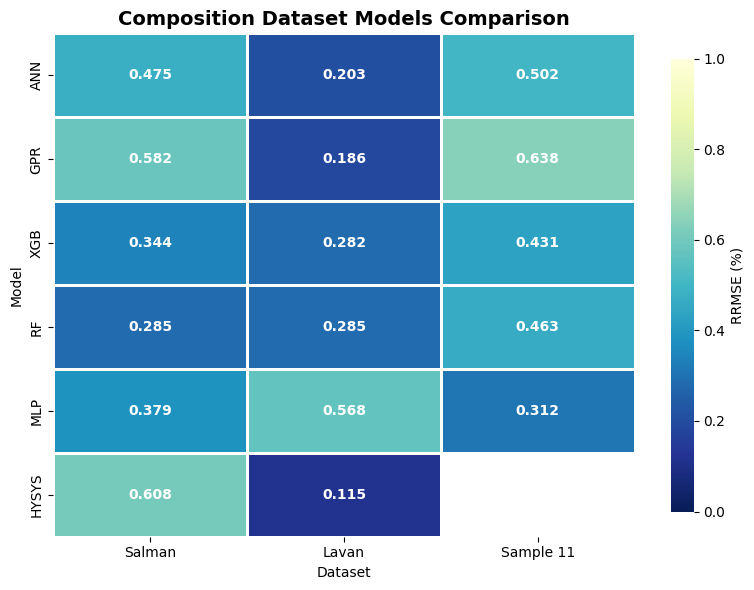

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,6))
sns.heatmap(
    rrmse_matrix,
    annot=True,
    fmt=".3f",
    cmap="YlGnBu_r",
    linewidths=1,
    vmin=0,
    vmax=1,
    cbar_kws={
        "label": "RRMSE (%)",
        "shrink": 0.9
    },
    annot_kws={
        "color": "white",
        "weight": "bold",
        "size": 10
    }
)


plt.title(
    "Composition Dataset Models Comparison",
    fontsize=14,
    fontweight="bold"
)

plt.ylabel("Model")
plt.xlabel("Dataset")

plt.tight_layout()
plt.show()

In [17]:
import pandas as pd

metrics_df = pd.DataFrame({

    "Model": [
        "ANN",
        "GPR",
        "XGB",
        "RF",
        "MLP",
        "HYSYS"
    ],

    "Salman": [
        0.475190,   # ANN2
        0.581532,   # GPR22
        0.343742,   # XGB222
        0.284871,   # RF222
        0.379236,   # MLP222
        0.608178    # HYSYS
    ],

    "Lavan": [
        0.203440,   # ANN2
        0.185975,   # GPR22
        0.282144,   # XGB222
        0.284968,   # RF222
        0.567560,   # MLP222
        0.115171    # HYSYS
    ],

    "Sample11": [
        0.501622,   # ANN2
        0.637843,   # GPR22
        0.431091,   # XGB222
        0.462703,   # RF222
        0.312277,   # MLP222
        np.nan      # HYSYS
    ]

})

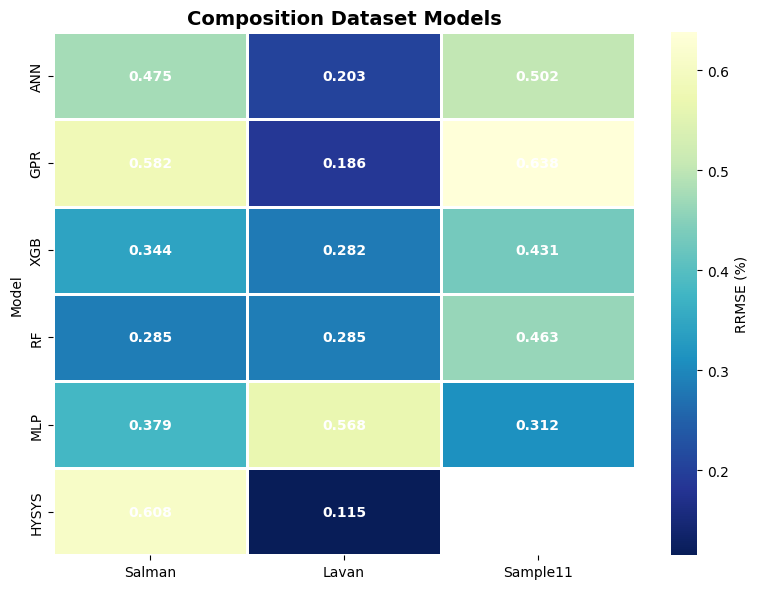

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt

heatmap_data = metrics_df.set_index("Model")

plt.figure(figsize=(8,6))

sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".3f",
    cmap="YlGnBu_r",
    linewidths=1,
    cbar_kws={
        "label":"RRMSE (%)",
        "location":"right"
    },
    annot_kws={
        "color":"white",
        "weight":"bold",
        "size":10
    }
)

plt.title(
    "Composition Dataset Models",
    fontsize=14,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

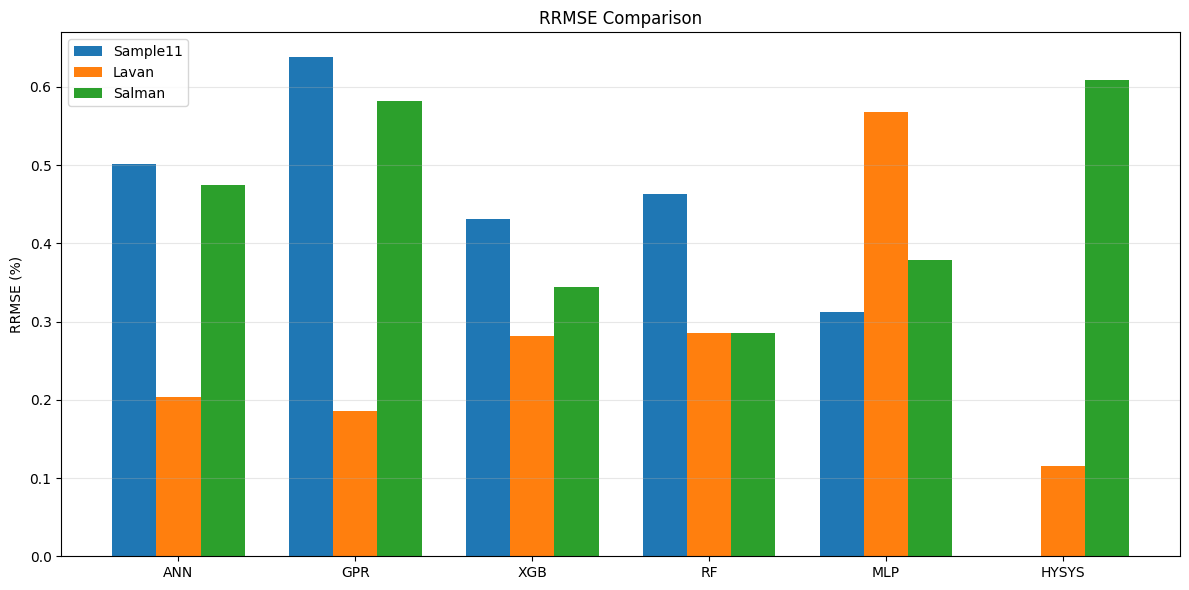

In [19]:
import numpy as np
import matplotlib.pyplot as plt

models = metrics_df["Model"]

x = np.arange(len(models))

width = 0.25

plt.figure(figsize=(12,6))

plt.bar(
    x-width,
    metrics_df["Sample11"],
    width,
    label="Sample11"
)

plt.bar(
    x,
    metrics_df["Lavan"],
    width,
    label="Lavan"
)

plt.bar(
    x+width,
    metrics_df["Salman"],
    width,
    label="Salman"
)

plt.xticks(
    x,
    models,
    rotation=0
)

plt.ylabel("RRMSE (%)")

plt.title(
    "RRMSE Comparison"
)

plt.legend()

plt.grid(
    alpha=0.3,
    axis="y"
)

plt.tight_layout()
plt.show()

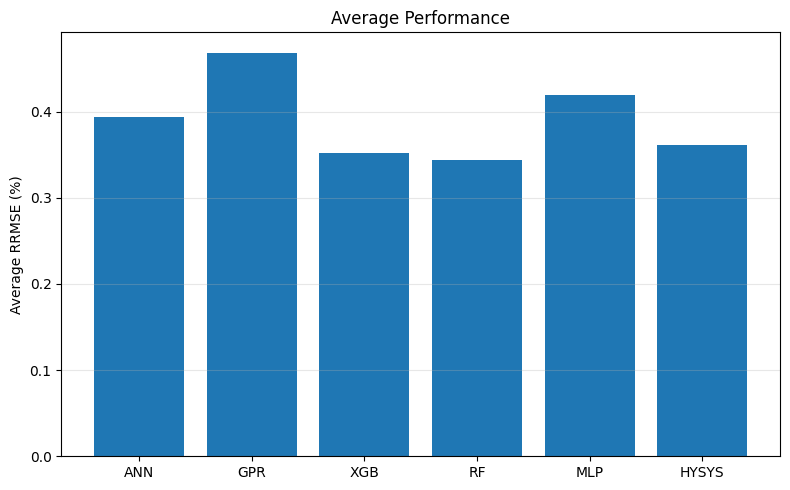

In [20]:
metrics_df["Average"] = metrics_df[
    ["Sample11","Lavan","Salman"]
].mean(axis=1)

plt.figure(figsize=(8,5))

plt.bar(
    metrics_df["Model"],
    metrics_df["Average"]
)

plt.ylabel("Average RRMSE (%)")

plt.title(
    "Average Performance"
)

plt.grid(
    alpha=0.3,
    axis="y"
)

plt.tight_layout()
plt.show()

  Model  Wins
0   ANN     0
1   GPR     1
2   XGB     0
3    RF     1
4   MLP     1


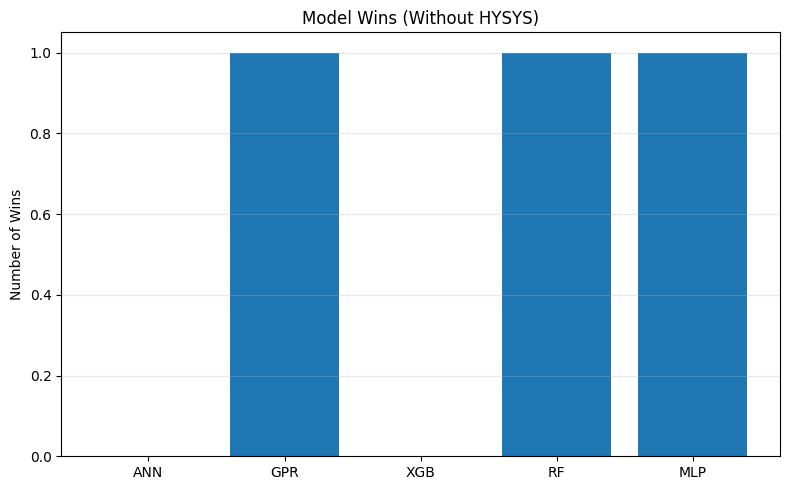

In [21]:
# ======================================
# REMOVE HYSYS
# ======================================

wins_models = metrics_df[
    metrics_df["Model"] != "HYSYS"
].copy()

# ======================================
# WIN COUNT
# ======================================

wins = {}

for model in wins_models["Model"]:
    wins[model] = 0

for dataset in [
    "Sample11",
    "Lavan",
    "Salman"
]:

    winner = wins_models.loc[
        wins_models[dataset].idxmin(),
        "Model"
    ]

    wins[winner] += 1

wins_df = pd.DataFrame({

    "Model": list(wins.keys()),
    "Wins": list(wins.values())

})

print(wins_df)

# ======================================
# PLOT
# ======================================

plt.figure(figsize=(8,5))

plt.bar(
    wins_df["Model"],
    wins_df["Wins"]
)

plt.ylabel("Number of Wins")

plt.title(
    "Model Wins (Without HYSYS)"
)

plt.grid(
    alpha=0.3,
    axis="y"
)

plt.tight_layout()
plt.show()

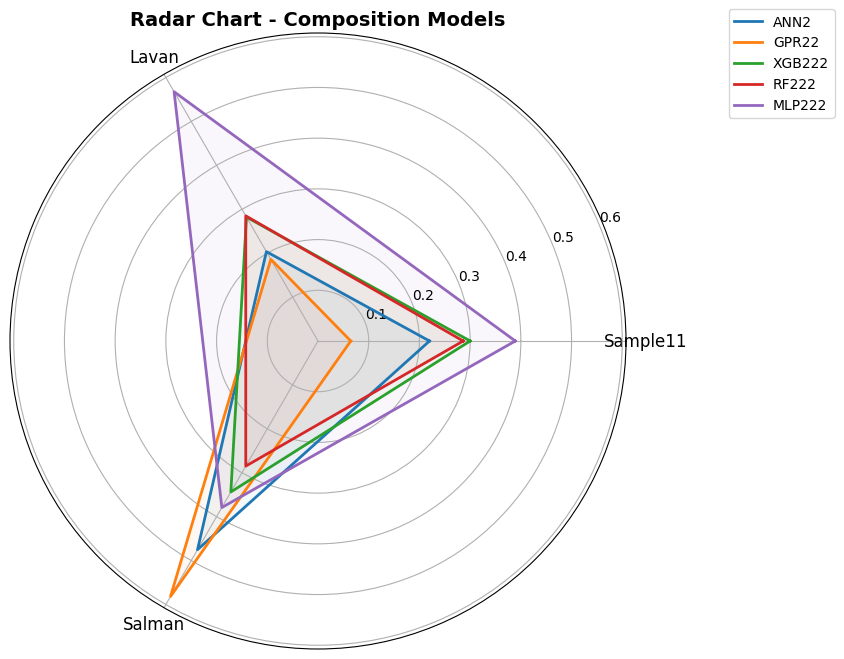

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ======================================
# DATA
# ======================================

radar_df = pd.DataFrame({

    "Model": [
        "ANN2",
        "GPR22",
        "XGB222",
        "RF222",
        "MLP222"
    ],

    "Sample11": [
        0.219883,
        0.064609,
        0.300099,
        0.286312,
        0.389119
    ],

    "Lavan": [
        0.203440,
        0.185975,
        0.282144,
        0.284968,
        0.567560
    ],

    "Salman": [
        0.475190,
        0.581532,
        0.343742,
        0.284871,
        0.379236
    ]

})

# ======================================
# REPLACE NaN
# ======================================

numeric_cols = [
    "Sample11",
    "Lavan",
    "Salman"
]

max_rrmse = radar_df[numeric_cols].max().max()

radar_df[numeric_cols] = radar_df[
    numeric_cols
].fillna(max_rrmse)

# ======================================
# RADAR SETUP
# ======================================

categories = numeric_cols

N = len(categories)

angles = np.linspace(
    0,
    2*np.pi,
    N,
    endpoint=False
).tolist()

angles += angles[:1]

# ======================================
# PLOT
# ======================================

fig = plt.figure(figsize=(8,8))

ax = plt.subplot(
    111,
    polar=True
)

for _, row in radar_df.iterrows():

    values = row[
        numeric_cols
    ].tolist()

    values += values[:1]

    ax.plot(
        angles,
        values,
        linewidth=2,
        label=row["Model"]
    )

    ax.fill(
        angles,
        values,
        alpha=0.05
    )

ax.set_xticks(
    angles[:-1]
)

ax.set_xticklabels(
    categories,
    fontsize=12
)

plt.title(
    "Radar Chart - Composition Models",
    fontsize=14,
    fontweight="bold"
)

plt.legend(
    bbox_to_anchor=(1.35,1.05)
)

plt.show()